# Effects of Experimental Addition of Algae and Shell Hash on an Infaunal Mudflat Community

**Chapter 3 — Field Experiment**  
**Associated publication:** McGarrigle, S.A. et al. Effects of experimental addition of algae and shell hash on an infaunal mudflat community. *Estuaries and Coasts*. https://doi.org/10.1007/s12237-023-01252-4  
**Language:** R

---

## Overview

This notebook contains the complete analysis pipeline for a field experiment examining the effects of green algae addition and crushed shell hash addition on sediment carbonate chemistry and the infaunal invertebrate community on an intertidal mudflat in the Bay of Fundy, Lepreau, NB (45°07'51.8" N, 66°28'27.8" W). The experiment ran from July to September 2020.

**Experimental design:**
- **Algae treatment (Trt_Nut):** None (0), Low (L), High (H)
- **Shell hash treatment (Trt_Shell):** None (0), Low (L), High (H)
- **Controls:** Procedural control (PC; disturbed, no addition) · Undisturbed control (UC)
- **Blocking:** 8 randomised blocks, 10 plots per block (one per treatment combination)
- **Sampling:** Month 1 (end of August) · Month 2 (end of September)
- **UC vs PC comparison:** No significant differences detected — only PC is presented in treatment analyses

**Multivariate note:** Community composition and biological trait analyses were originally conducted in PRIMER-e v.7. Section 8 reproduces those analyses in R using the `vegan` package.

---

**Notebook structure:**
1. Setup and data loading
2. Data preparation
3. Sediment pH
4. Sediment characteristics
5. Treatment coverage
6. Univariate community metrics
7. Individual species abundances
8. Multivariate community composition
9. Biological trait analysis
10. Figures

---
*carbonate_chemistry_invertebrates/field_experiment - Samantha McGarrigle*

## 1. Setup and Data Loading

In [10]:
library(dplyr)
library(tidyr)
library(ggplot2)
library(ggpubr)
library(ggthemes)
library(nlme)
library(lme4)
library(lmerTest)
library(glmmTMB)
library(car)
library(multcomp)
library(DHARMa)
library(vegan)      # multivariate section only
library(readxl)

# All data files are in the data/ subfolder relative to this notebook.
# Set your working directory to field_experiment/ before running.

ph       <- read.csv("data/pHprofiles_plots.csv",       header = TRUE)
grain    <- read.csv("data/Sed_grainsize.csv",          header = TRUE)
omsh     <- read.csv("data/Sed_OMSH.csv",               header = TRUE)
unibio   <- read.csv("data/community_univarbiodiv.csv", header = TRUE)
abund    <- read.csv("data/Abund.csv",                  header = TRUE)
cover    <- read.csv("data/ShellCoverage_2020.csv",     header = TRUE)
traits   <- read.csv("data/traits_codes_2020.csv",      header = TRUE)
trait_wt <- read.csv("data/trait_abundweight_2020.csv", header = TRUE, sep = "\t")
comm_wide <- read.csv("data/community_2020.csv",        header = TRUE)

cat("Data loaded successfully\n")
cat("pH profiles rows:        ", nrow(ph),     "\n")
cat("Grain size rows:         ", nrow(grain),  "\n")
cat("OM/Shell hash rows:      ", nrow(omsh),   "\n")
cat("Univariate biodiv rows:  ", nrow(unibio), "\n")
cat("Species abundance rows:  ", nrow(abund),  "\n")
cat("Coverage rows:           ", nrow(cover),  "\n")

Data loaded successfully
pH profiles rows:         3452 
Grain size rows:          80 
OM/Shell hash rows:       72 
Univariate biodiv rows:   160 
Species abundance rows:   144 
Coverage rows:            90 


## 2. Data Preparation

### Treatment levels
- `Trt_Nut`: `0` (no algae), `L` (low), `H` (high)
- `Trt_Shell`: `0` (no shell), `L` (low), `H` (high)
- UC excluded from all treatment analyses
- Month 0 is the pre-treatment baseline, retained for pH context only

### Community matrix reshaping
The PRIMER-e master file has species as rows and samples as columns. This is transposed to the standard R/vegan format (samples as rows, species as columns) for Section 8.

In [11]:
# ── Factor coding — pH ────────────────────────────────────────────────────────
ph$Rep       <- as.factor(ph$Rep)
ph$Month     <- as.factor(ph$Month)
ph$Core      <- as.factor(ph$Core)
ph$Trt_Nut   <- factor(ph$Trt_Nut,   levels = c("0", "L", "H"))
ph$Trt_Shell <- factor(ph$Trt_Shell, levels = c("0", "L", "H"))
ph$Trt       <- as.factor(ph$Trt)

# ── Factor coding — grain size ────────────────────────────────────────────────
grain$Rep       <- as.factor(grain$Block)
grain$Trt       <- as.factor(grain$Trt)
grain$Trt_Nut   <- factor(grain$Trt_Nut,   levels = c("0", "L", "H"))
grain$Trt_Shell <- factor(grain$Trt_Shell, levels = c("0", "L", "H"))

# ── Factor coding — OM / shell hash ──────────────────────────────────────────
omsh$Rep       <- as.factor(omsh$Rep)
omsh$Trt       <- as.factor(omsh$Trt)
omsh$Trt_Nut   <- factor(omsh$Trt_Nut,   levels = c("0", "L", "H"))
omsh$Trt_Shell <- factor(omsh$Trt_Shell, levels = c("0", "L", "H"))

# ── Factor coding — univariate biodiversity ───────────────────────────────────
unibio$Rep       <- as.factor(unibio$Rep)
unibio$Month     <- as.factor(unibio$Month)
unibio$Trt_Nut   <- factor(unibio$Trt_Nut,   levels = c("UC", "0", "L", "H"))
unibio$Trt_Shell <- factor(unibio$Trt_Shell, levels = c("UC", "0", "L", "H"))
unibio$Trt       <- as.factor(unibio$Trt)

# ── Factor coding — species abundance ────────────────────────────────────────
abund$Rep       <- as.factor(abund$Rep)
abund$Month     <- as.factor(abund$Month)
abund$Trt_Nut   <- factor(abund$Trt_Nut,   levels = c("0", "L", "H"))
abund$Trt_Shell <- factor(abund$Trt_Shell, levels = c("0", "L", "H"))
abund$Trt       <- as.factor(abund$Trt)

# ── Factor coding — coverage ──────────────────────────────────────────────────
cover$Rep       <- as.factor(cover$Rep)
cover$Month     <- as.factor(cover$Month)
cover$Trt_Nut   <- factor(cover$Trt_Nut,   levels = c("0", "L", "H"))
cover$Trt_Shell <- factor(cover$Trt_Shell, levels = c("0", "L", "H"))
cover$Trt       <- as.factor(cover$Trt)

cat("Factor levels set\n")
cat("Trt_Nut levels:",   levels(abund$Trt_Nut),   "\n")
cat("Trt_Shell levels:", levels(abund$Trt_Shell), "\n")

Factor levels set
Trt_Nut levels: 0 L H 
Trt_Shell levels: 0 L H 


In [12]:
# ── UC exclusion and month subsetting ─────────────────────────────────────────
unibio_trt <- filter(unibio, Trt != "UC")
unibio1    <- filter(unibio_trt, Month == "1")
unibio2    <- filter(unibio_trt, Month == "2")

abund1 <- filter(abund, Month == "1")
abund2 <- filter(abund, Month == "2")

ph_control <- filter(ph, Trt %in% c("UC", "PC"))
ph_M0      <- filter(ph, Month == "0")
ph_M1      <- filter(ph, Month == "1", Trt != "UC")
ph_M2      <- filter(ph, Month == "2", Trt != "UC")

grain1 <- filter(grain, Trt != "UC")
omsh1  <- filter(omsh,  Trt != "UC")

cat("Subsets created\n")
cat("abund1 rows (Month 1):", nrow(abund1), "\n")
cat("abund2 rows (Month 2):", nrow(abund2), "\n")

Subsets created
abund1 rows (Month 1): 72 
abund2 rows (Month 2): 72 


In [13]:
# ── Community matrix reshaping: wide (PRIMER) → long (vegan) ─────────────────
meta_rows <- c("Month", "Rep", "Trt_Nut", "Trt_Shell", "Trt")
first_col <- names(comm_wide)[1]
species_rows <- comm_wide[[first_col]][!comm_wide[[first_col]] %in% meta_rows]

comm_sp_raw <- comm_wide[comm_wide[[first_col]] %in% species_rows, ]
rownames(comm_sp_raw) <- comm_sp_raw[[first_col]]
comm_sp_raw <- comm_sp_raw[, -1]

comm_meta_raw <- comm_wide[comm_wide[[first_col]] %in% meta_rows, ]
rownames(comm_meta_raw) <- comm_meta_raw[[first_col]]
comm_meta_raw <- comm_meta_raw[, -1]
comm_meta <- as.data.frame(t(comm_meta_raw))

# Transpose species matrix
comm_mat <- t(comm_sp_raw)
comm_mat <- apply(comm_mat, 2, as.numeric)
rownames(comm_mat) <- rownames(comm_meta)

# Drop any columns that are entirely NA after numeric conversion
# (blank separator columns from PRIMER-e export)
comm_mat <- comm_mat[, colSums(is.na(comm_mat)) == 0]

comm_df <- cbind(comm_meta, as.data.frame(comm_mat))
comm_df$Month     <- as.factor(comm_df$Month)
comm_df$Rep       <- as.factor(comm_df$Rep)
comm_df$Trt_Nut   <- factor(comm_df$Trt_Nut,   levels = c("0", "L", "H"))
comm_df$Trt_Shell <- factor(comm_df$Trt_Shell, levels = c("0", "L", "H"))
comm_df <- filter(comm_df, Trt != "UC")

sp_cols      <- names(comm_df)[!names(comm_df) %in% c("Month","Rep","Trt_Nut","Trt_Shell","Trt")]
comm_sp_only <- comm_df[, sp_cols]

cat("Community matrix prepared:\n")
cat("  Samples:", nrow(comm_df), "\n")
cat("  Species:", ncol(comm_sp_only), "\n")
cat("  NAs in species matrix:", sum(is.na(comm_sp_only)), "\n")

Community matrix prepared:
  Samples: 144 
  Species: 21 
  NAs in species matrix: 0 


In [14]:
# Convert Sample column to character type once
trait_wt$Sample <- as.character(trait_wt$Sample)

# Parse Sample column into Month, Trt, Rep
trait_wt$Month <- as.factor(sapply(strsplit(trait_wt$Sample, " "), `[`, 1))
trait_wt$Trt   <- sapply(strsplit(trait_wt$Sample, " "), `[`, 2)
trait_wt$Rep   <- as.factor(sapply(strsplit(trait_wt$Sample, " "), `[`, 3))

# Build treatment key manually
trt_key <- data.frame(
  Trt       = c("N0S0","N0SL","N0SH","NLS0","NLSL","NLSH","NHS0","NHSL","NHSH"),
  Trt_Nut   = factor(c("0","0","0","L","L","L","H","H","H"), levels = c("0","L","H")),
  Trt_Shell = factor(c("0","L","H","0","L","H","0","L","H"), levels = c("0","L","H"))
)

# Join treatment metadata and exclude PC (N0S0)
trait_df <- trait_wt %>%
  filter(Trt != "N0S0") %>%
  left_join(trt_key, by = "Trt")

trait_cols <- names(trait_df)[!names(trait_df) %in%
               c("Sample","Trt","Rep","Month","Trt_Nut","Trt_Shell")]

cat("Trait matrix rows:", nrow(trait_df), "\n")
cat("NAs in Trt_Nut:", sum(is.na(trait_df$Trt_Nut)), "\n")
cat("Months:", levels(trait_df$Month), "\n")
cat("Trait cols:", paste(trait_cols, collapse = ", "), "\n")

Trait matrix rows: 128 
NAs in Trt_Nut: 0 
Months: 1 2 
Trait cols: AMBI, sediment_reworking_mode, environmental_position, longevity, max_size, feeding_mode, dispersal, exposure_potential, position_sediment, habitat_structure, Motility, Hypoxia_sensitivity 


## 3. Sediment pH

Sediment pH was measured at 0.5 cm intervals from 0 to 3 cm depth. Three profiles were measured per core. Models include Trt_Nut × Trt_Shell × Depth as fixed effects with Rep/Core as random effects. Distribution family is selected by AIC. Months are analysed separately.

Month 0 (UC only, pre-treatment) is summarised but not included in treatment models. UC vs PC is compared using LME with Rep as random effect across Months 1 and 2.

In [47]:
# ── Month 0 baseline summary (UC only) ───────────────────────────────────────
ph_M0 %>%
  group_by(Depth) %>%
  summarise(mean_pH = mean(pH, na.rm = TRUE),
            sd_pH   = sd(pH,   na.rm = TRUE),
            n       = n(), .groups = "drop")

Depth,mean_pH,sd_pH,n
<dbl>,<dbl>,<dbl>,<int>
0.0,7.264667,0.2728649,15
0.5,7.236000,0.1576524,15
1.0,7.202667,0.1370332,15
1.5,7.237333,0.1520088,15
2.0,7.316000,0.1992773,15
2.5,7.366667,0.2040541,15
3.0,7.344000,0.3506076,15


In [48]:
# ── UC vs PC comparison — Months 1 and 2 ─────────────────────────────────────
# Month 0 has UC only (pre-disturbance baseline) — comparison uses Months 1 & 2
ph_ctrl_m12 <- filter(ph_control, Month %in% c("1", "2"))
ctrl_pH.lme <- lme(pH ~ Trt,
                   random    = ~ 1 | Rep,
                   na.action = na.exclude,
                   data      = ph_ctrl_m12)
anova(ctrl_pH.lme)

,numDF,denDF,F-value,p-value
,<int>,<dbl>,<dbl>,<dbl>
(Intercept),1,663,4.905538e+05,0.000000
Trt,1,663,3.637480e-02,0.848802


In [49]:
# ── Month 1 sediment pH — distribution family selection ───────────────────────
M1_1.glmer <- glmer(pH ~ Trt_Nut * Trt_Shell * Depth + (1 | Rep / Core),
                    family = gaussian(link = "identity"), data = ph_M1)
M1_2.glmer <- glmer(pH ~ Trt_Nut * Trt_Shell * Depth + (1 | Rep / Core),
                    family = gaussian(link = "inverse"),  data = ph_M1)
M1_3.glmer <- glmer(pH ~ Trt_Nut * Trt_Shell * Depth + (1 | Rep / Core),
                    family = Gamma(link = "log"),         data = ph_M1)
AIC(M1_1.glmer, M1_2.glmer, M1_3.glmer)

Warning message in glmer(pH ~ Trt_Nut * Trt_Shell * Depth + (1 | Rep/Core), family = gaussian(link = "identity"), :
"calling glmer() with family=gaussian (identity link) as a shortcut to lmer() is deprecated; please call lmer() directly"


,df,AIC
,<dbl>,<dbl>
M1_1.glmer,21,-2021.117
M1_2.glmer,21,-2215.615
M1_3.glmer,21,-2199.050


In [50]:
# ── Month 1 sediment pH — best model ─────────────────────────────────────────
# Use best family from AIC comparison above
# gaussian inverse had best AIC in original analysis
M1.glmer <- glmer(pH ~ Trt_Nut * Trt_Shell * Depth + (1 | Rep / Core),
                  family = gaussian(link = "inverse"), data = ph_M1)
summary(M1.glmer)
car::Anova(M1.glmer, type = 3)

# Post-hoc: Shell treatment (marginal across depths)
M1_shell.lmer <- lmer(pH ~ Trt_Shell + (1 | Rep), data = ph_M1)
summary(glht(M1_shell.lmer, linfct = mcp(Trt_Shell = "Tukey")))

# Post-hoc: Depth (marginal across shell treatments)
ph_M1$Depth_f <- as.factor(ph_M1$Depth)
M1_depth.lmer <- lmer(pH ~ Depth_f + (1 | Rep), data = ph_M1)
summary(glht(M1_depth.lmer, linfct = mcp(Depth_f = "Tukey")))

# Summary statistics
group_by(ph_M1, Trt_Shell, Depth) %>%
  summarise(mean_pH = mean(pH, na.rm = TRUE),
            sd_pH   = sd(pH,   na.rm = TRUE), .groups = "drop")


Correlation matrix not shown by default, as p = 18 > 12.
Use print(obj, correlation=TRUE)  or
    vcov(obj)        if you need it




Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: gaussian  ( inverse )
Formula: pH ~ Trt_Nut * Trt_Shell * Depth + (1 | Rep/Core)
   Data: ph_M1

      AIC       BIC    logLik -2*log(L)  df.resid 
  -2215.6   -2104.0    1128.8   -2257.6      1479 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-4.5078 -0.5728  0.0544  0.6292  2.8215 

Random effects:
 Groups   Name        Variance  Std.Dev.
 Core:Rep (Intercept) 3.750e-05 0.006123
 Rep      (Intercept) 6.231e-06 0.002496
Number of obs: 1500, groups:  Core:Rep, 72; Rep, 8

Fixed effects:
                            Estimate Std. Error t value Pr(>|z|)    
(Intercept)                1.372e-01  3.983e-04 344.566  < 2e-16 ***
Trt_NutL                   5.525e-04  5.468e-04   1.010  0.31226    
Trt_NutH                  -2.707e-04  5.448e-04  -0.497  0.61919    
Trt_ShellL                -1.038e-03  5.427e-04  -1.913  0.05580 .  
Trt_ShellH                -1.410e-03  5.436e

,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
(Intercept),1.187258e+05,1,0.000000e+00
Trt_Nut,2.354456e+00,2,3.081317e-01
Trt_Shell,7.222082e+00,2,2.702370e-02
Depth,2.376599e+01,1,1.087879e-06
Trt_Nut:Trt_Shell,7.045161e+00,4,1.335208e-01
Trt_Nut:Depth,1.707972e+00,2,4.257147e-01
Trt_Shell:Depth,6.486296e+00,2,3.904080e-02
Trt_Nut:Trt_Shell:Depth,3.140400e+00,4,5.346109e-01



	 Simultaneous Tests for General Linear Hypotheses

Multiple Comparisons of Means: Tukey Contrasts


Fit: lmer(formula = pH ~ Trt_Shell + (1 | Rep), data = ph_M1)

Linear Hypotheses:
           Estimate Std. Error z value Pr(>|z|)    
L - 0 == 0 0.022855   0.008160   2.801   0.0141 *  
H - 0 == 0 0.041451   0.008172   5.072   <0.001 ***
H - L == 0 0.018595   0.008172   2.275   0.0595 .  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
(Adjusted p values reported -- single-step method)


Warning message in RET$pfunction("adjusted", ...):
"Completion with error > abseps"



	 Simultaneous Tests for General Linear Hypotheses

Multiple Comparisons of Means: Tukey Contrasts


Fit: lmer(formula = pH ~ Depth_f + (1 | Rep), data = ph_M1)

Linear Hypotheses:
                Estimate Std. Error z value Pr(>|z|)    
0.5 - 0 == 0   -0.020509   0.012037  -1.704  0.61341    
1 - 0 == 0     -0.015139   0.012037  -1.258  0.87116    
1.5 - 0 == 0    0.009815   0.012037   0.815  0.98349    
2 - 0 == 0      0.036906   0.012066   3.059  0.03603 *  
2.5 - 0 == 0    0.064454   0.012109   5.323  < 0.001 ***
3 - 0 == 0      0.082558   0.012109   6.818  < 0.001 ***
1 - 0.5 == 0    0.005370   0.012037   0.446  0.99941    
1.5 - 0.5 == 0  0.030324   0.012037   2.519  0.15241    
2 - 0.5 == 0    0.057415   0.012066   4.759  < 0.001 ***
2.5 - 0.5 == 0  0.084963   0.012109   7.016  < 0.001 ***
3 - 0.5 == 0    0.103068   0.012109   8.512  < 0.001 ***
1.5 - 1 == 0    0.024954   0.012037   2.073  0.36926    
2 - 1 == 0      0.052045   0.012066   4.313  < 0.001 ***
2.5 - 1 == 0    0.07

Trt_Shell,Depth,mean_pH,sd_pH
<fct>,<dbl>,<dbl>,<dbl>
0,0.0,7.315972,0.18729851
0,0.5,7.294861,0.14658548
0,1.0,7.295694,0.12858741
0,1.5,7.316389,0.13465978
0,2.0,7.349859,0.12686881
0,2.5,7.381127,0.12874725
0,3.0,7.404366,0.12378244
L,0.0,7.323472,0.17578924
L,0.5,7.298333,0.14777219


In [51]:
# ── Month 2 sediment pH — distribution family selection ───────────────────────
M2_1.lmer  <- lmer(pH ~ Trt_Nut * Trt_Shell * Depth + (1 | Rep / Core), data = ph_M2)
M2_2.glmer <- glmer(pH ~ Trt_Nut * Trt_Shell * Depth + (1 | Rep / Core),
                    family = gaussian(link = "inverse"), data = ph_M2)
M2_3.glmer <- glmer(pH ~ Trt_Nut * Trt_Shell * Depth + (1 | Rep / Core),
                    family = Gamma(link = "log"), data = ph_M2)
AIC(M2_1.lmer, M2_2.glmer, M2_3.glmer)

# Best model
M2.lmer <- lmer(pH ~ Trt_Nut * Trt_Shell * Depth + (1 | Rep / Core), data = ph_M2)
summary(M2.lmer)
car::Anova(M2.lmer, type = 3)

,df,AIC
,<dbl>,<dbl>
M2_1.lmer,21,-2796.151
M2_2.glmer,21,-3022.727
M2_3.glmer,21,-3007.024



Correlation matrix not shown by default, as p = 18 > 12.
Use print(obj, correlation=TRUE)  or
    vcov(obj)        if you need it




Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: pH ~ Trt_Nut * Trt_Shell * Depth + (1 | Rep/Core)
   Data: ph_M2

REML criterion at convergence: -2838.2

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-5.6210 -0.5972  0.0052  0.5830  5.4662 

Random effects:
 Groups   Name        Variance Std.Dev.
 Core:Rep (Intercept) 0.004176 0.06463 
 Rep      (Intercept) 0.001044 0.03231 
 Residual             0.007341 0.08568 
Number of obs: 1511, groups:  Core:Rep, 73; Rep, 8

Fixed effects:
                            Estimate Std. Error         df t value Pr(>|t|)    
(Intercept)                7.387e+00  2.760e-02  6.463e+01 267.636  < 2e-16 ***
Trt_NutL                  -5.142e-02  3.599e-02  7.972e+01  -1.429  0.15701    
Trt_NutH                  -8.987e-04  3.599e-02  7.972e+01  -0.025  0.98014    
Trt_ShellL                -1.060e-02  3.599e-02  7.972e+01  -0.295  0.76911    
Trt_ShellH                -3.561e-03  3.600e-02  7.977

,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
(Intercept),7.162924e+04,1,0.000000000
Trt_Nut,2.632059e+00,2,0.268198058
Trt_Shell,8.936237e-02,2,0.956302319
Depth,6.662957e+00,1,0.009843744
Trt_Nut:Trt_Shell,1.392968e+00,4,0.845416340
Trt_Nut:Depth,3.241536e+00,2,0.197746775
Trt_Shell:Depth,4.495341e+00,2,0.105645027
Trt_Nut:Trt_Shell:Depth,1.157845e+00,4,0.884989217


## 4. Sediment Characteristics

Sediment characteristics were measured from cores collected at the end of the experiment. Each variable is modelled with Trt_Nut × Trt_Shell as fixed effects and Rep as random intercept. Distribution family is selected by AIC. Separate GLMs with Rep as a fixed factor examine spatial (block-level) variation.

In [52]:
# ── Porosity ──────────────────────────────────────────────────────────────────
poro1.lmer  <- lmer(porosity ~ Trt_Shell * Trt_Nut + (1 | Rep), data = grain1)
poro2.glmer <- glmer(porosity ~ Trt_Shell * Trt_Nut + (1 | Rep),
                     family = Gamma(), data = grain1)
AIC(poro1.lmer, poro2.glmer)
car::Anova(poro1.lmer, type = 3)

poro_spatial.glm <- glm(porosity ~ Rep, family = gaussian(link = "identity"), data = grain1)
car::Anova(poro_spatial.glm, type = 3)
summary(glht(poro_spatial.glm, linfct = mcp(Rep = "Tukey")))

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
"Model failed to converge with max|grad| = 0.00341616 (tol = 0.002, component 1)
  See ?lme4::convergence and ?lme4::troubleshooting."
Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
"Model is nearly unidentifiable: very large eigenvalue
 - Rescale variables?"


,df,AIC
,<dbl>,<dbl>
poro1.lmer,11,373.2225
poro2.glmer,11,392.5373


,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
(Intercept),451.169726,1,4.013761e-100
Trt_Shell,3.404614,2,1.822626e-01
Trt_Nut,2.278840,2,3.200046e-01
Trt_Shell:Trt_Nut,3.309804,4,5.073805e-01


,LR Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
Rep,31.99691,7,4.066952e-05


Warning message in RET$pfunction("adjusted", ...):
"Completion with error > abseps"
Warning message in RET$pfunction("adjusted", ...):
"Completion with error > abseps"



	 Simultaneous Tests for General Linear Hypotheses

Multiple Comparisons of Means: Tukey Contrasts


Fit: glm(formula = porosity ~ Rep, family = gaussian(link = "identity"), 
    data = grain1)

Linear Hypotheses:
           Estimate Std. Error z value Pr(>|z|)    
2 - 1 == 0   3.6383     1.4446   2.519  0.18724    
3 - 1 == 0  -0.8885     1.4446  -0.615  0.99870    
4 - 1 == 0   1.4819     1.4446   1.026  0.97071    
5 - 1 == 0   5.8584     1.4446   4.055  0.00141 ** 
6 - 1 == 0   0.8986     1.4446   0.622  0.99860    
7 - 1 == 0   3.2494     1.4446   2.249  0.32234    
8 - 1 == 0   2.7417     1.4446   1.898  0.55224    
3 - 2 == 0  -4.5268     1.4446  -3.134  0.03702 *  
4 - 2 == 0  -2.1564     1.4446  -1.493  0.81176    
5 - 2 == 0   2.2200     1.4446   1.537  0.78749    
6 - 2 == 0  -2.7397     1.4446  -1.896  0.55331    
7 - 2 == 0  -0.3889     1.4446  -0.269  0.99999    
8 - 2 == 0  -0.8966     1.4446  -0.621  0.99862    
4 - 3 == 0   2.3703     1.4446   1.641  0.72531    
5 - 3

In [53]:
# ── Mean grain size ───────────────────────────────────────────────────────────
# Note: Mean grain size (phi scale) can be negative — Gamma family not applicable
mean1.lmer <- lmer(Mean ~ Trt_Shell * Trt_Nut + (1 | Rep), data = grain1)

car::Anova(mean1.lmer, type = 3)

mean_spatial.glm <- glm(Mean ~ Rep, family = gaussian(link = "identity"), data = grain1)
car::Anova(mean_spatial.glm, type = 3)
summary(glht(mean_spatial.glm, linfct = mcp(Rep = "Tukey")))

,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
(Intercept),7.2809547,1,0.006968949
Trt_Shell,0.6833767,2,0.710569634
Trt_Nut,0.6633563,2,0.717718292
Trt_Shell:Trt_Nut,4.7477235,4,0.314175435


,LR Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
Rep,88.87039,7,2.110287e-16



	 Simultaneous Tests for General Linear Hypotheses

Multiple Comparisons of Means: Tukey Contrasts


Fit: glm(formula = Mean ~ Rep, family = gaussian(link = "identity"), 
    data = grain1)

Linear Hypotheses:
           Estimate Std. Error z value Pr(>|z|)    
2 - 1 == 0 -0.26104    0.23930  -1.091  0.95892    
3 - 1 == 0  0.99046    0.23930   4.139  < 0.001 ***
4 - 1 == 0 -0.07086    0.23930  -0.296  0.99999    
5 - 1 == 0 -0.26414    0.23930  -1.104  0.95627    
6 - 1 == 0  0.82032    0.23930   3.428  0.01390 *  
7 - 1 == 0  1.00870    0.23930   4.215  < 0.001 ***
8 - 1 == 0  1.02400    0.23930   4.279  < 0.001 ***
3 - 2 == 0  1.25150    0.23930   5.230  < 0.001 ***
4 - 2 == 0  0.19018    0.23930   0.795  0.99344    
5 - 2 == 0 -0.00310    0.23930  -0.013  1.00000    
6 - 2 == 0  1.08136    0.23930   4.519  < 0.001 ***
7 - 2 == 0  1.26974    0.23930   5.306  < 0.001 ***
8 - 2 == 0  1.28504    0.23930   5.370  < 0.001 ***
4 - 3 == 0 -1.06132    0.23930  -4.435  < 0.001 ***
5 - 3 == 

In [54]:
# ── Skewness ──────────────────────────────────────────────────────────────────
skew1.lmer <- lmer(Skewness ~ Trt_Shell * Trt_Nut + (1 | Rep), data = grain1)

car::Anova(skew1.lmer, type = 3)

skew_spatial.glm <- glm(Skewness ~ Rep, family = gaussian(link = "identity"), data = grain1)
car::Anova(skew_spatial.glm, type = 3)
summary(glht(skew_spatial.glm, linfct = mcp(Rep = "Tukey")))

,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
(Intercept),0.2557928,1,0.6130254
Trt_Shell,1.5920917,2,0.4511092
Trt_Nut,0.3325416,2,0.8468169
Trt_Shell:Trt_Nut,1.6075438,4,0.8074356


,LR Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
Rep,90.1507,7,1.15214e-16



	 Simultaneous Tests for General Linear Hypotheses

Multiple Comparisons of Means: Tukey Contrasts


Fit: glm(formula = Skewness ~ Rep, family = gaussian(link = "identity"), 
    data = grain1)

Linear Hypotheses:
           Estimate Std. Error z value Pr(>|z|)    
2 - 1 == 0   4.6026    14.8445   0.310  0.99999    
3 - 1 == 0 -65.8299    14.8445  -4.435  < 0.001 ***
4 - 1 == 0   0.4675    14.8445   0.031  1.00000    
5 - 1 == 0  -5.1747    14.8445  -0.349  0.99997    
6 - 1 == 0 -62.8313    14.8445  -4.233  < 0.001 ***
7 - 1 == 0 -78.1390    14.8445  -5.264  < 0.001 ***
8 - 1 == 0 -72.4963    14.8445  -4.884  < 0.001 ***
3 - 2 == 0 -70.4325    14.8445  -4.745  < 0.001 ***
4 - 2 == 0  -4.1351    14.8445  -0.279  0.99999    
5 - 2 == 0  -9.7773    14.8445  -0.659  0.99797    
6 - 2 == 0 -67.4339    14.8445  -4.543  < 0.001 ***
7 - 2 == 0 -82.7416    14.8445  -5.574  < 0.001 ***
8 - 2 == 0 -77.0989    14.8445  -5.194  < 0.001 ***
4 - 3 == 0  66.2974    14.8445   4.466  < 0.001 ***
5 - 3

In [55]:
# ── Kurtosis ──────────────────────────────────────────────────────────────────
kurt1.lmer  <- lmer(Kurtosis ~ Trt_Shell * Trt_Nut + (1 | Rep), data = grain1)
kurt2.glmer <- glmer(Kurtosis ~ Trt_Shell * Trt_Nut + (1 | Rep),
                     family = Gamma(), data = grain1)
AIC(kurt1.lmer, kurt2.glmer)
car::Anova(kurt2.glmer, type = 3)

kurt_spatial.glm <- glm(Kurtosis ~ Rep, family = gaussian(link = "identity"), data = grain1)
car::Anova(kurt_spatial.glm, type = 3)
summary(glht(kurt_spatial.glm, linfct = mcp(Rep = "Tukey")))

,df,AIC
,<dbl>,<dbl>
kurt1.lmer,11,104.88202
kurt2.glmer,11,67.57145


,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
(Intercept),197.3290749,1,7.992943e-45
Trt_Shell,0.0404309,2,9.799875e-01
Trt_Nut,0.4561124,2,7.960795e-01
Trt_Shell:Trt_Nut,3.5782697,4,4.660775e-01


,LR Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
Rep,19.24266,7,0.007460213


Warning message in RET$pfunction("adjusted", ...):
"Completion with error > abseps"



	 Simultaneous Tests for General Linear Hypotheses

Multiple Comparisons of Means: Tukey Contrasts


Fit: glm(formula = Kurtosis ~ Rep, family = gaussian(link = "identity"), 
    data = grain1)

Linear Hypotheses:
           Estimate Std. Error z value Pr(>|z|)   
2 - 1 == 0  0.24988    0.17441   1.433   0.8423   
3 - 1 == 0  0.60340    0.17441   3.460   0.0127 * 
4 - 1 == 0 -0.04827    0.17441  -0.277   1.0000   
5 - 1 == 0  0.22117    0.17441   1.268   0.9107   
6 - 1 == 0  0.17051    0.17441   0.978   0.9776   
7 - 1 == 0  0.29263    0.17441   1.678   0.7018   
8 - 1 == 0  0.35232    0.17441   2.020   0.4681   
3 - 2 == 0  0.35352    0.17441   2.027   0.4633   
4 - 2 == 0 -0.29815    0.17441  -1.709   0.6810   
5 - 2 == 0 -0.02871    0.17441  -0.165   1.0000   
6 - 2 == 0 -0.07937    0.17441  -0.455   0.9998   
7 - 2 == 0  0.04276    0.17441   0.245   1.0000   
8 - 2 == 0  0.10245    0.17441   0.587   0.9990   
4 - 3 == 0 -0.65167    0.17441  -3.736    <0.01 **
5 - 3 == 0 -0.38223 

In [56]:
# ── Organic matter ────────────────────────────────────────────────────────────
org1.lmer    <- lmer(OM ~ Trt_Shell * Trt_Nut + (1 | Rep), data = omsh1)
org3.glmmTMB <- glmmTMB(OM ~ Trt_Shell * Trt_Nut + (1 | Rep),
                         family = beta_family(), data = omsh1)
AIC(org1.lmer, org3.glmmTMB)
car::Anova(org3.glmmTMB, type = 3)

org_spatial.glm <- glm(OM ~ Rep, family = gaussian(link = "identity"), data = omsh1)
car::Anova(org_spatial.glm, type = 3)
summary(glht(org_spatial.glm, linfct = mcp(Rep = "Tukey")))

,df,AIC
,<dbl>,<dbl>
org1.lmer,11,-419.2146
org3.glmmTMB,11,-512.2208


,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
(Intercept),1.786602e+03,1,0.0000000
Trt_Shell,2.485736e+00,2,0.2885555
Trt_Nut,5.274239e-03,2,0.9973664
Trt_Shell:Trt_Nut,5.512241e+00,4,0.2386556


,LR Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
Rep,24.66139,7,0.0008711061


Warning message in RET$pfunction("adjusted", ...):
"Completion with error > abseps"
Warning message in RET$pfunction("adjusted", ...):
"Completion with error > abseps"
Warning message in RET$pfunction("adjusted", ...):
"Completion with error > abseps"
Warning message in RET$pfunction("adjusted", ...):
"Completion with error > abseps"
Warning message in RET$pfunction("adjusted", ...):
"Completion with error > abseps"



	 Simultaneous Tests for General Linear Hypotheses

Multiple Comparisons of Means: Tukey Contrasts


Fit: glm(formula = OM ~ Rep, family = gaussian(link = "identity"), 
    data = omsh1)

Linear Hypotheses:
             Estimate Std. Error z value Pr(>|z|)  
2 - 1 == 0  0.0001959  0.0028829   0.068   1.0000  
3 - 1 == 0 -0.0075458  0.0028829  -2.617   0.1495  
4 - 1 == 0 -0.0067162  0.0028829  -2.330   0.2777  
5 - 1 == 0  0.0016738  0.0028829   0.581   0.9991  
6 - 1 == 0 -0.0071535  0.0028829  -2.481   0.2036  
7 - 1 == 0 -0.0029503  0.0028829  -1.023   0.9711  
8 - 1 == 0 -0.0065968  0.0028829  -2.288   0.3001  
3 - 2 == 0 -0.0077417  0.0028829  -2.685   0.1269  
4 - 2 == 0 -0.0069121  0.0028829  -2.398   0.2426  
5 - 2 == 0  0.0014778  0.0028829   0.513   0.9996  
6 - 2 == 0 -0.0073494  0.0028829  -2.549   0.1746  
7 - 2 == 0 -0.0031462  0.0028829  -1.091   0.9588  
8 - 2 == 0 -0.0067928  0.0028829  -2.356   0.2627  
4 - 3 == 0  0.0008296  0.0028829   0.288   1.0000  
5 - 3 == 0  

In [57]:
# ── Carbonate (shell hash proportion) ────────────────────────────────────────
carb1.lmer    <- lmer(Carb ~ Trt_Shell * Trt_Nut + (1 | Rep), data = omsh1)
carb3.glmmTMB <- glmmTMB(Carb ~ Trt_Shell * Trt_Nut + (1 | Rep),
                          family = beta_family(), data = omsh1)
AIC(carb1.lmer, carb3.glmmTMB)
car::Anova(carb3.glmmTMB, type = 3)

carb_spatial.glm <- glm(Carb ~ Rep, family = gaussian(link = "identity"), data = omsh1)
car::Anova(carb_spatial.glm, type = 3)
summary(glht(carb_spatial.glm, linfct = mcp(Rep = "Tukey")))

,df,AIC
,<dbl>,<dbl>
carb1.lmer,11,-317.8880
carb3.glmmTMB,11,-429.6709


,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
(Intercept),467.898451,1,9.185087e-104
Trt_Shell,0.486671,2,7.840084e-01
Trt_Nut,3.686323,2,1.583161e-01
Trt_Shell:Trt_Nut,3.514364,4,4.756977e-01


,LR Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
Rep,6.651449,7,0.4660498



	 Simultaneous Tests for General Linear Hypotheses

Multiple Comparisons of Means: Tukey Contrasts


Fit: glm(formula = Carb ~ Rep, family = gaussian(link = "identity"), 
    data = omsh1)

Linear Hypotheses:
             Estimate Std. Error z value Pr(>|z|)
2 - 1 == 0 -0.0124065  0.0070063  -1.771    0.640
3 - 1 == 0 -0.0104753  0.0070063  -1.495    0.810
4 - 1 == 0 -0.0085524  0.0070063  -1.221    0.926
5 - 1 == 0 -0.0152194  0.0070063  -2.172    0.369
6 - 1 == 0 -0.0055461  0.0070063  -0.792    0.994
7 - 1 == 0 -0.0048328  0.0070063  -0.690    0.997
8 - 1 == 0 -0.0106277  0.0070063  -1.517    0.799
3 - 2 == 0  0.0019313  0.0070063   0.276    1.000
4 - 2 == 0  0.0038542  0.0070063   0.550    0.999
5 - 2 == 0 -0.0028128  0.0070063  -0.401    1.000
6 - 2 == 0  0.0068604  0.0070063   0.979    0.977
7 - 2 == 0  0.0075738  0.0070063   1.081    0.961
8 - 2 == 0  0.0017788  0.0070063   0.254    1.000
4 - 3 == 0  0.0019229  0.0070063   0.274    1.000
5 - 3 == 0 -0.0047441  0.0070063  -0.677

## 5. Treatment Coverage

Shell and algae coverage were recorded at the start of the experiment (Month 0), end of Month 1, and end of Month 2 to track persistence of experimental additions.

In [17]:
cover_trt <- filter(cover, Trt != "UC")

cover_trt %>%
  group_by(Month, Trt_Shell, Trt_Nut) %>%
  summarise(
    mean_shell = mean(Shell, na.rm = TRUE),
    sd_shell   = sd(Shell,   na.rm = TRUE),
    mean_algae = mean(Algae, na.rm = TRUE),
    sd_algae   = sd(Algae,   na.rm = TRUE),
    .groups    = "drop"
  )

Month,Trt_Shell,Trt_Nut,mean_shell,sd_shell,mean_algae,sd_algae
<fct>,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>
0,0,0,3.286667,1.4211732,0.08200000,0.06009992
0,0,L,2.913333,1.0556672,20.77266667,10.48875809
0,0,H,2.436667,1.0103630,20.15800000,5.06509496
0,L,0,9.330000,5.7789013,0.02839667,0.04065664
0,L,L,4.410000,1.2044916,27.93266667,13.42507580
0,L,H,4.143333,1.2320850,24.86333333,8.03039877
0,H,0,13.970000,5.2670580,0.02333333,0.02417299
0,H,L,5.043333,1.6464609,20.35133333,8.71625724
0,H,H,5.436667,2.8655250,33.69466667,15.56270598


## 6. Univariate Community Metrics

Species richness (S), total abundance (N), Pielou's evenness (J'), Shannon index (H'), and Simpson index (1-λ') are modelled with Trt_Nut × Trt_Shell as fixed effects and Rep as random intercept. Months are analysed separately due to differences in abiotic conditions between months. Distribution family selected by AIC.

In [18]:
# ── Species richness ──────────────────────────────────────────────────────────
# Month 1
specrich1.lmer <- lmer(S ~ Trt_Shell * Trt_Nut + (1 | Rep), data = unibio1)

summary(specrich1.lmer)
car::Anova(specrich1.lmer, type = 3)

# Month 2
specrich2.lmer <- lmer(S ~ Trt_Shell * Trt_Nut + (1 | Rep), data = unibio2)
summary(specrich2.lmer)
car::Anova(specrich2.lmer, type = 3)

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: S ~ Trt_Shell * Trt_Nut + (1 | Rep)
   Data: unibio1

REML criterion at convergence: 259.8

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-1.81178 -0.68479 -0.06826  0.55160  2.20902 

Random effects:
 Groups   Name        Variance Std.Dev.
 Rep      (Intercept) 2.136    1.461   
 Residual             2.076    1.441   
Number of obs: 72, groups:  Rep, 8

Fixed effects:
                      Estimate Std. Error         df t value Pr(>|t|)    
(Intercept)          5.750e+00  7.256e-01  2.061e+01   7.924 1.09e-07 ***
Trt_ShellL          -1.250e-01  7.205e-01  5.600e+01  -0.173    0.863    
Trt_ShellH          -1.250e-01  7.205e-01  5.600e+01  -0.173    0.863    
Trt_NutL             5.000e-01  7.205e-01  5.600e+01   0.694    0.491    
Trt_NutH             8.750e-01  7.205e-01  5.600e+01   1.214    0.230    
Trt_ShellL:Trt_NutL -1.250e-01  1.019e+00  5.600e+01  -0.123    0.903 

,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
(Intercept),62.79227488,1,2.296980e-15
Trt_Shell,0.04013378,2,9.801331e-01
Trt_Nut,1.48494983,2,4.759346e-01
Trt_Shell:Trt_Nut,0.70903010,4,9.502107e-01


Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: S ~ Trt_Shell * Trt_Nut + (1 | Rep)
   Data: unibio2

REML criterion at convergence: 249.7

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.0094 -0.5649 -0.0393  0.6165  2.5593 

Random effects:
 Groups   Name        Variance Std.Dev.
 Rep      (Intercept) 1.258    1.122   
 Residual             1.841    1.357   
Number of obs: 72, groups:  Rep, 8

Fixed effects:
                    Estimate Std. Error      df t value Pr(>|t|)    
(Intercept)           6.3750     0.6224 27.1667  10.242 7.91e-11 ***
Trt_ShellL           -0.8750     0.6784 56.0000  -1.290   0.2024    
Trt_ShellH           -0.7500     0.6784 56.0000  -1.106   0.2736    
Trt_NutL              0.3750     0.6784 56.0000   0.553   0.5826    
Trt_NutH             -1.1250     0.6784 56.0000  -1.658   0.1028    
Trt_ShellL:Trt_NutL   0.2500     0.9594 56.0000   0.261   0.7954    
Trt_ShellH:Trt_NutL   0.3750     0.9594 5

,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
(Intercept),104.905887,1,1.280769e-24
Trt_Shell,1.946645,2,3.778256e-01
Trt_Nut,5.296686,2,7.076839e-02
Trt_Shell:Trt_Nut,6.730261,4,1.508480e-01


In [19]:
# ── Total abundance ───────────────────────────────────────────────────────────
# Month 1
abund1.glmer <- glmer(N ~ Trt_Shell * Trt_Nut + (1 | Rep),
                      family = poisson(link = "log"), data = unibio1)
summary(abund1.glmer)
car::Anova(abund1.glmer, type = 3)

# Month 2
abund2.glmer <- glmer(N ~ Trt_Shell * Trt_Nut + (1 | Rep),
                      family = poisson(link = "log"), data = unibio2)
summary(abund2.glmer)
car::Anova(abund2.glmer, type = 3)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: poisson  ( log )
Formula: N ~ Trt_Shell * Trt_Nut + (1 | Rep)
   Data: unibio1

      AIC       BIC    logLik -2*log(L)  df.resid 
   1096.2    1118.9    -538.1    1076.2        62 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-6.0224 -2.0285 -0.2038  1.3034  8.2217 

Random effects:
 Groups Name        Variance Std.Dev.
 Rep    (Intercept) 0.1114   0.3337  
Number of obs: 72, groups:  Rep, 8

Fixed effects:
                    Estimate Std. Error z value Pr(>|z|)    
(Intercept)          4.01117    0.12684  31.624  < 2e-16 ***
Trt_ShellL           0.05429    0.06461   0.840  0.40078    
Trt_ShellH           0.07242    0.06433   1.126  0.26028    
Trt_NutL             0.09023    0.06406   1.409  0.15898    
Trt_NutH             0.43368    0.05945   7.295 2.98e-13 ***
Trt_ShellL:Trt_NutL  0.25521    0.08702   2.933  0.00336 ** 
Trt_ShellH:Trt_NutL -0.39333    0.09380  -

,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
(Intercept),1000.098029,1,1.709850e-219
Trt_Shell,1.359036,2,5.068613e-01
Trt_Nut,63.890758,2,1.337514e-14
Trt_Shell:Trt_Nut,111.887876,4,2.879413e-23


Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: poisson  ( log )
Formula: N ~ Trt_Shell * Trt_Nut + (1 | Rep)
   Data: unibio2

      AIC       BIC    logLik -2*log(L)  df.resid 
    887.4     910.1    -433.7     867.4        62 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-4.4329 -1.9275 -0.3599  1.4066  5.8429 

Random effects:
 Groups Name        Variance Std.Dev.
 Rep    (Intercept) 0.1642   0.4052  
Number of obs: 72, groups:  Rep, 8

Fixed effects:
                    Estimate Std. Error z value Pr(>|z|)    
(Intercept)          4.15313    0.14956  27.769  < 2e-16 ***
Trt_ShellL           0.06329    0.05930   1.067  0.28580    
Trt_ShellH           0.02509    0.05985   0.419  0.67506    
Trt_NutL             0.16370    0.05791   2.827  0.00470 ** 
Trt_NutH             0.25494    0.05674   4.493 7.01e-06 ***
Trt_ShellL:Trt_NutL -0.14513    0.08202  -1.770  0.07680 .  
Trt_ShellH:Trt_NutL  0.08977    0.08059   

,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
(Intercept),771.092106,1,1.040644e-169
Trt_Shell,1.160868,2,5.596555e-01
Trt_Nut,20.362732,2,3.786945e-05
Trt_Shell:Trt_Nut,42.736209,4,1.173760e-08


In [20]:
# ── Pielou's evenness ─────────────────────────────────────────────────────────
even1.lmer    <- lmer(J. ~ Trt_Shell * Trt_Nut + (1 | Rep), data = unibio1)
even3.glmmTMB <- glmmTMB(J. ~ Trt_Shell * Trt_Nut + (1 | Rep),
                          family = beta_family(), data = unibio1)
AIC(even1.lmer, even3.glmmTMB)
car::Anova(even3.glmmTMB, type = 3)

,df,AIC
,<dbl>,<dbl>
even1.lmer,11,-32.91720
even3.glmmTMB,11,-76.53504


,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
(Intercept),2.721757,1,0.09898903
Trt_Shell,3.958294,2,0.13818705
Trt_Nut,2.886999,2,0.23610007
Trt_Shell:Trt_Nut,6.308693,4,0.17725046


In [21]:
# ── Shannon index ─────────────────────────────────────────────────────────────
# Scale to (0,1) for beta family
unibio1$ShanInd <- unibio1$H..loge. / 2
ShanInd1.lmer    <- lmer(ShanInd ~ Trt_Shell * Trt_Nut + (1 | Rep), data = unibio1)
ShanInd3.glmmTMB <- glmmTMB(ShanInd ~ Trt_Shell * Trt_Nut + (1 | Rep),
                              family = beta_family(), data = unibio1)
AIC(ShanInd1.lmer, ShanInd3.glmmTMB)
car::Anova(ShanInd3.glmmTMB, type = 3)

,df,AIC
,<dbl>,<dbl>
ShanInd1.lmer,11,-14.29093
ShanInd3.glmmTMB,11,-51.86287


,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
(Intercept),0.007279865,1,0.9320053
Trt_Shell,1.074543683,2,0.5843403
Trt_Nut,3.719150264,2,0.1557388
Trt_Shell:Trt_Nut,4.409712812,4,0.3533878


In [22]:
# ── Simpson index ─────────────────────────────────────────────────────────────
SimpInd1.lmer   <- lmer(X1.Lambda. ~ Trt_Shell * Trt_Nut + (1 | Rep), data = unibio1)
SimpInd3.glmmTMB <- glmmTMB(X1.Lambda. ~ Trt_Shell * Trt_Nut + (1 | Rep),
                              family = beta_family(), data = unibio1)
AIC(SimpInd1.lmer, SimpInd3.glmmTMB)
car::Anova(SimpInd3.glmmTMB, type = 3)

,df,AIC
,<dbl>,<dbl>
SimpInd1.lmer,11,-23.58211
SimpInd3.glmmTMB,11,-64.47196


,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
(Intercept),0.09837225,1,0.7537918
Trt_Shell,2.47964029,2,0.2894363
Trt_Nut,4.59260050,2,0.1006305
Trt_Shell:Trt_Nut,6.05462807,4,0.1951056


## 7. Individual Species Abundances

The 10 most abundant species are modelled individually. For each species, candidate models (LME, Poisson GLMM, negative binomial GLMM via `glmer.nb`, and negative binomial via `glmmTMB`) are compared by AIC. The best model is then used for inference. Months are analysed separately.

In [23]:
# ── Corophium volutator ───────────────────────────────────────────────────────
# Month 1
coro1.lmer    <- lmer(Corophium ~ Trt_Shell * Trt_Nut + (1 | Rep), data = abund1)
coro2.glmer   <- glmer(Corophium ~ Trt_Shell * Trt_Nut + (1 | Rep),
                        family = poisson(link = "log"), data = abund1)
coro3.glmer.nb <- glmer.nb(Corophium ~ Trt_Shell * Trt_Nut + (1 | Rep), data = abund1)
AIC(coro1.lmer, coro2.glmer, coro3.glmer.nb)
car::Anova(coro1.lmer, type = 3)

# Month 2
coro1b.lmer    <- lmer(Corophium ~ Trt_Shell * Trt_Nut + (1 | Rep), data = abund2)
coro2b.glmer   <- glmer(Corophium ~ Trt_Shell * Trt_Nut + (1 | Rep),
                         family = poisson(link = "log"), data = abund2)
coro3b.glmer.nb <- glmer.nb(Corophium ~ Trt_Shell * Trt_Nut + (1 | Rep), data = abund2)
AIC(coro1b.lmer, coro2b.glmer, coro3b.glmer.nb)
car::Anova(coro1b.lmer, type = 3)

,df,AIC
,<dbl>,<dbl>
coro1.lmer,11,566.5955
coro2.glmer,10,777.8707
coro3.glmer.nb,11,610.5339


,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
(Intercept),19.4369329,1,1.039768e-05
Trt_Shell,0.4915185,2,7.821105e-01
Trt_Nut,1.1949058,2,5.502113e-01
Trt_Shell:Trt_Nut,1.1934848,4,8.791701e-01


,df,AIC
,<dbl>,<dbl>
coro1b.lmer,11,543.8642
coro2b.glmer,10,715.0683
coro3b.glmer.nb,11,586.6536


,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
(Intercept),23.111967,1,1.528365e-06
Trt_Shell,1.765207,2,4.137045e-01
Trt_Nut,1.121564,2,5.707625e-01
Trt_Shell:Trt_Nut,4.860939,4,3.018659e-01


In [24]:
# ── Tubificoides benedii ──────────────────────────────────────────────────────
# Month 1
tub1.lmer    <- lmer(Tubificoides ~ Trt_Shell * Trt_Nut + (1 | Rep), data = abund1)
tub2.glmer   <- glmer(Tubificoides ~ Trt_Shell * Trt_Nut + (1 | Rep),
                       family = poisson(link = "log"), data = abund1)
tub3.glmer.nb <- glmer.nb(Tubificoides ~ Trt_Shell * Trt_Nut + (1 | Rep), data = abund1)
AIC(tub1.lmer, tub2.glmer, tub3.glmer.nb)
car::Anova(tub3.glmer.nb, type = 3)

# Month 2
tub1b.lmer    <- lmer(Tubificoides ~ Trt_Shell * Trt_Nut + (1 | Rep), data = abund2)
tub2b.glmer   <- glmer(Tubificoides ~ Trt_Shell * Trt_Nut + (1 | Rep),
                        family = poisson(link = "log"), data = abund2)
tub3b.glmer.nb <- glmer.nb(Tubificoides ~ Trt_Shell * Trt_Nut + (1 | Rep), data = abund2)
AIC(tub1b.lmer, tub2b.glmer, tub3b.glmer.nb)
car::Anova(tub1b.lmer, type = 3)

,df,AIC
,<dbl>,<dbl>
tub1.lmer,11,530.4048
tub2.glmer,10,717.5835
tub3.glmer.nb,11,520.9090


,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
(Intercept),39.0482046,1,4.134692e-10
Trt_Shell,0.2919691,2,8.641711e-01
Trt_Nut,3.9225108,2,1.406817e-01
Trt_Shell:Trt_Nut,6.2675997,4,1.800352e-01


,df,AIC
,<dbl>,<dbl>
tub1b.lmer,11,514.1419
tub2b.glmer,10,583.3852
tub3b.glmer.nb,11,521.2155


,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
(Intercept),12.915586,1,0.0003258574
Trt_Shell,2.282918,2,0.3193526774
Trt_Nut,1.088304,2,0.5803335906
Trt_Shell:Trt_Nut,6.776056,4,0.1482066201


In [25]:
# ── Clitellio arenarius ───────────────────────────────────────────────────────
# Month 1
cli1.lmer    <- lmer(Clitellio ~ Trt_Shell * Trt_Nut + (1 | Rep), data = abund1)
cli2.glmer   <- glmer(Clitellio ~ Trt_Shell * Trt_Nut + (1 | Rep),
                       family = poisson(link = "log"), data = abund1)
cli3.glmer.nb <- glmer.nb(Clitellio ~ Trt_Shell * Trt_Nut + (1 | Rep), data = abund1)
AIC(cli1.lmer, cli2.glmer, cli3.glmer.nb)
car::Anova(cli3.glmer.nb, type = 3)

# Spatial variation check for Clitellio
cli_spatial.glm <- glm(Clitellio ~ Rep, family = gaussian(link = "identity"), data = abund1)
car::Anova(cli_spatial.glm, type = 3)
summary(glht(cli_spatial.glm, linfct = mcp(Rep = "Tukey")))

# Month 2
cli1b.lmer    <- lmer(Clitellio ~ Trt_Shell * Trt_Nut + (1 | Rep), data = abund2)
cli2b.glmer   <- glmer(Clitellio ~ Trt_Shell * Trt_Nut + (1 | Rep),
                        family = poisson(link = "log"), data = abund2)
cli3b.glmer.nb <- glmer.nb(Clitellio ~ Trt_Shell * Trt_Nut + (1 | Rep), data = abund2)
AIC(cli1b.lmer, cli2b.glmer, cli3b.glmer.nb)
car::Anova(cli3b.glmer.nb, type = 3)

,df,AIC
,<dbl>,<dbl>
cli1.lmer,11,512.2262
cli2.glmer,10,678.9852
cli3.glmer.nb,11,448.6766


,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
(Intercept),4.9340139,1,0.0263330842
Trt_Shell,0.2349361,2,0.8891689364
Trt_Nut,15.6218874,2,0.0004052754
Trt_Shell:Trt_Nut,13.0364843,4,0.0110988943


,LR Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
Rep,138.3273,7,1.138875e-26


Warning message in RET$pfunction("adjusted", ...):
"Completion with error > abseps"



	 Simultaneous Tests for General Linear Hypotheses

Multiple Comparisons of Means: Tukey Contrasts


Fit: glm(formula = Clitellio ~ Rep, family = gaussian(link = "identity"), 
    data = abund1)

Linear Hypotheses:
           Estimate Std. Error z value Pr(>|z|)    
2 - 1 == 0 -14.0000     4.2261  -3.313   0.0209 *  
3 - 1 == 0 -10.5556     4.2261  -2.498   0.1961    
4 - 1 == 0 -11.3333     4.2261  -2.682   0.1278    
5 - 1 == 0 -11.1111     4.2261  -2.629   0.1453    
6 - 1 == 0  -5.5556     4.2261  -1.315   0.8936    
7 - 1 == 0  27.1111     4.2261   6.415   <0.001 ***
8 - 1 == 0  -5.3333     4.2261  -1.262   0.9128    
3 - 2 == 0   3.4444     4.2261   0.815   0.9923    
4 - 2 == 0   2.6667     4.2261   0.631   0.9985    
5 - 2 == 0   2.8889     4.2261   0.684   0.9974    
6 - 2 == 0   8.4444     4.2261   1.998   0.4831    
7 - 2 == 0  41.1111     4.2261   9.728   <0.001 ***
8 - 2 == 0   8.6667     4.2261   2.051   0.4472    
4 - 3 == 0  -0.7778     4.2261  -0.184   1.0000    
5 - 

,df,AIC
,<dbl>,<dbl>
cli1b.lmer,11,524.5711
cli2b.glmer,10,558.9102
cli3b.glmer.nb,11,442.0757


,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
(Intercept),7.5495154,1,0.006002621
Trt_Shell,3.7904090,2,0.150287599
Trt_Nut,0.6707707,2,0.715062476
Trt_Shell:Trt_Nut,5.0608610,4,0.281109591


In [26]:
# ── Nematoda spp. ─────────────────────────────────────────────────────────────
# Month 1
nem1.lmer    <- lmer(Nematoda ~ Trt_Shell * Trt_Nut + (1 | Rep), data = abund1)
nem2.glmer   <- glmer(Nematoda ~ Trt_Shell * Trt_Nut + (1 | Rep),
                       family = poisson(link = "log"), data = abund1)
nem3.glmer.nb <- glmer.nb(Nematoda ~ Trt_Shell * Trt_Nut + (1 | Rep), data = abund1)
AIC(nem1.lmer, nem2.glmer, nem3.glmer.nb)
car::Anova(nem3.glmer.nb, type = 3)

# Month 2
nem1b.lmer    <- lmer(Nematoda ~ Trt_Shell * Trt_Nut + (1 | Rep), data = abund2)
nem2b.glmer   <- glmer(Nematoda ~ Trt_Shell * Trt_Nut + (1 | Rep),
                        family = poisson(link = "log"), data = abund2)
nem3b.glmer.nb <- glmer.nb(Nematoda ~ Trt_Shell * Trt_Nut + (1 | Rep), data = abund2)
AIC(nem1b.lmer, nem2b.glmer, nem3b.glmer.nb)
car::Anova(nem3b.glmer.nb, type = 3)

,df,AIC
,<dbl>,<dbl>
nem1.lmer,11,465.8155
nem2.glmer,10,428.2016
nem3.glmer.nb,11,354.8396


,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
(Intercept),1.5236231,1,0.2170720
Trt_Shell,2.2817599,2,0.3195377
Trt_Nut,0.5352894,2,0.7651796
Trt_Shell:Trt_Nut,2.9050769,4,0.5738342


,df,AIC
,<dbl>,<dbl>
nem1b.lmer,11,571.8764
nem2b.glmer,10,790.8947
nem3b.glmer.nb,11,483.4850


,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
(Intercept),2.343646,1,0.125794847
Trt_Shell,4.653530,2,0.097610997
Trt_Nut,10.377293,2,0.005579553
Trt_Shell:Trt_Nut,4.988055,4,0.288525361


In [27]:
# ── Mya arenaria ─────────────────────────────────────────────────────────────
# Month 1
mya1.lmer     <- lmer(Mya ~ Trt_Shell * Trt_Nut + (1 | Rep), data = abund1)
mya2.glmer    <- glmer(Mya ~ Trt_Shell * Trt_Nut + (1 | Rep),
                        family = poisson(link = "log"), data = abund1)
mya4.glmmTMB  <- glmmTMB(Mya ~ Trt_Shell * Trt_Nut + (1 | Rep), family = nbinom1, data = abund1)
mya5.glmmTMB  <- glmmTMB(Mya ~ Trt_Shell * Trt_Nut + (1 | Rep), family = nbinom2, data = abund1)
mya6.glmmTMB  <- glmmTMB(Mya ~ Trt_Shell * Trt_Nut + (1 | Rep),
                          family = poisson(link = "log"), data = abund1)
AIC(mya1.lmer, mya4.glmmTMB, mya5.glmmTMB, mya6.glmmTMB)
car::Anova(mya6.glmmTMB, type = 3)

# Month 2
mya1b.lmer    <- lmer(Mya ~ Trt_Shell * Trt_Nut + (1 | Rep), data = abund2)
mya4b.glmmTMB <- glmmTMB(Mya ~ Trt_Shell * Trt_Nut + (1 | Rep), family = nbinom1, data = abund2)
mya5b.glmmTMB <- glmmTMB(Mya ~ Trt_Shell * Trt_Nut + (1 | Rep), family = nbinom2, data = abund2)
AIC(mya1b.lmer, mya4b.glmmTMB, mya5b.glmmTMB)
car::Anova(mya4b.glmmTMB, type = 3)

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
"Model failed to converge with max|grad| = 0.0231278 (tol = 0.002, component 1)
  See ?lme4::convergence and ?lme4::troubleshooting."


,df,AIC
,<dbl>,<dbl>
mya1.lmer,11,229.5862
mya4.glmmTMB,11,152.2046
mya5.glmmTMB,11,152.4743
mya6.glmmTMB,10,150.4751


,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
(Intercept),5.300031,1,0.02132504
Trt_Shell,4.549199,2,0.10283811
Trt_Nut,3.075307,2,0.21488478
Trt_Shell:Trt_Nut,7.368470,4,0.11765101


,df,AIC
,<dbl>,<dbl>
mya1b.lmer,11,417.2466
mya4b.glmmTMB,11,378.2402
mya5b.glmmTMB,11,378.9598


,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
(Intercept),10.656933,1,0.001096591
Trt_Shell,1.754713,2,0.415880776
Trt_Nut,1.660369,2,0.435968756
Trt_Shell:Trt_Nut,6.118943,4,0.190439862


In [28]:
# ── Hediste diversicolor ──────────────────────────────────────────────────────
# Month 1
hed1.lmer     <- lmer(Hediste ~ Trt_Shell * Trt_Nut + (1 | Rep), data = abund1)
hed4.glmmTMB  <- glmmTMB(Hediste ~ Trt_Shell * Trt_Nut + (1 | Rep), family = nbinom1, data = abund1)
hed5.glmmTMB  <- glmmTMB(Hediste ~ Trt_Shell * Trt_Nut + (1 | Rep), family = nbinom2, data = abund1)
hed6.glmmTMB  <- glmmTMB(Hediste ~ Trt_Shell * Trt_Nut + (1 | Rep),
                          family = poisson(link = "log"), data = abund1)
AIC(hed1.lmer, hed4.glmmTMB, hed5.glmmTMB, hed6.glmmTMB)
car::Anova(hed4.glmmTMB, type = 3)

# Month 2
hed1b.lmer    <- lmer(Hediste ~ Trt_Shell * Trt_Nut + (1 | Rep), data = abund2)
hed3b.glmer.nb <- glmer.nb(Hediste ~ Trt_Shell * Trt_Nut + (1 | Rep), data = abund2)
hed4b.glmmTMB <- glmmTMB(Hediste ~ Trt_Shell * Trt_Nut + (1 | Rep), family = nbinom1, data = abund2)
AIC(hed1b.lmer, hed3b.glmer.nb, hed4b.glmmTMB)
car::Anova(hed3b.glmer.nb, type = 3)

,df,AIC
,<dbl>,<dbl>
hed1.lmer,11,305.1016
hed4.glmmTMB,11,170.6454
hed5.glmmTMB,11,171.9763
hed6.glmmTMB,10,180.2070


,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
(Intercept),1.3685286,1,0.2420648
Trt_Shell,1.2969889,2,0.5228323
Trt_Nut,0.8153873,2,0.6651826
Trt_Shell:Trt_Nut,4.6011171,4,0.3307254


Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
"Model failed to converge with max|grad| = 0.00229935 (tol = 0.002, component 1)
  See ?lme4::convergence and ?lme4::troubleshooting."
Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
"Model failed to converge with max|grad| = 0.00578906 (tol = 0.002, component 1)
  See ?lme4::convergence and ?lme4::troubleshooting."


,df,AIC
,<dbl>,<dbl>
hed1b.lmer,11,268.8037
hed3b.glmer.nb,11,134.9520
hed4b.glmmTMB,11,135.5292


,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
(Intercept),3.270772,1,0.07052443
Trt_Shell,5.042812,2,0.08034657
Trt_Nut,3.346020,2,0.18768126
Trt_Shell:Trt_Nut,5.618131,4,0.22953915


In [29]:
# ── Streblospio benedicti ─────────────────────────────────────────────────────
# Month 1
streb1.lmer    <- lmer(Streblospio ~ Trt_Shell * Trt_Nut + (1 | Rep), data = abund1)
streb4.glmmTMB <- glmmTMB(Streblospio ~ Trt_Shell * Trt_Nut + (1 | Rep),
                            family = nbinom1, data = abund1)
streb5.glmmTMB <- glmmTMB(Streblospio ~ Trt_Shell * Trt_Nut + (1 | Rep),
                            family = nbinom2, data = abund1)
streb6.glmmTMB <- glmmTMB(Streblospio ~ Trt_Shell * Trt_Nut + (1 | Rep),
                            family = poisson(link = "log"), data = abund1)
AIC(streb1.lmer, streb4.glmmTMB, streb5.glmmTMB, streb6.glmmTMB)
car::Anova(streb4.glmmTMB, type = 3)

# Spatial variation check
streb_spatial.glm <- glm(Streblospio ~ Rep, family = gaussian(link = "identity"), data = abund1)
car::Anova(streb_spatial.glm, type = 3)
summary(glht(streb_spatial.glm, linfct = mcp(Rep = "Tukey")))

# Month 2
streb1b.lmer    <- lmer(Streblospio ~ Trt_Shell * Trt_Nut + (1 | Rep), data = abund2)
streb6b.glmmTMB <- glmmTMB(Streblospio ~ Trt_Shell * Trt_Nut + (1 | Rep),
                             family = poisson(link = "log"), data = abund2)
AIC(streb1b.lmer, streb6b.glmmTMB)
car::Anova(streb6b.glmmTMB, type = 3)

,df,AIC
,<dbl>,<dbl>
streb1.lmer,11,263.6487
streb4.glmmTMB,11,180.5728
streb5.glmmTMB,11,181.0375
streb6.glmmTMB,10,181.7816


,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
(Intercept),1.102031,1,0.293820850
Trt_Shell,0.336379,2,0.845193659
Trt_Nut,12.275633,2,0.002159634
Trt_Shell:Trt_Nut,7.624942,4,0.106324435


,LR Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
Rep,13.58356,7,0.05910364


Warning message in RET$pfunction("adjusted", ...):
"Completion with error > abseps"
Warning message in RET$pfunction("adjusted", ...):
"Completion with error > abseps"



	 Simultaneous Tests for General Linear Hypotheses

Multiple Comparisons of Means: Tukey Contrasts


Fit: glm(formula = Streblospio ~ Rep, family = gaussian(link = "identity"), 
    data = abund1)

Linear Hypotheses:
           Estimate Std. Error z value Pr(>|z|)  
2 - 1 == 0  -2.3333     0.7505  -3.109   0.0396 *
3 - 1 == 0  -1.2222     0.7505  -1.629   0.7330  
4 - 1 == 0  -1.7778     0.7505  -2.369   0.2568  
5 - 1 == 0  -2.0000     0.7505  -2.665   0.1337  
6 - 1 == 0  -1.6667     0.7505  -2.221   0.3390  
7 - 1 == 0  -1.4444     0.7505  -1.925   0.5336  
8 - 1 == 0  -0.7778     0.7505  -1.036   0.9690  
3 - 2 == 0   1.1111     0.7505   1.480   0.8183  
4 - 2 == 0   0.5556     0.7505   0.740   0.9958  
5 - 2 == 0   0.3333     0.7505   0.444   0.9998  
6 - 2 == 0   0.6667     0.7505   0.888   0.9872  
7 - 2 == 0   0.8889     0.7505   1.184   0.9366  
8 - 2 == 0   1.5556     0.7505   2.073   0.4331  
4 - 3 == 0  -0.5556     0.7505  -0.740   0.9958  
5 - 3 == 0  -0.7778     0.7505  

,df,AIC
,<dbl>,<dbl>
streb1b.lmer,11,271.2573
streb6b.glmmTMB,10,128.0582


,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
(Intercept),0.7592126,1,0.38357504
Trt_Shell,1.3594024,2,0.50676838
Trt_Nut,7.7149928,2,0.02112081
Trt_Shell:Trt_Nut,5.1757758,4,0.26973259


In [30]:
# ── Limecola balthica ─────────────────────────────────────────────────────────
# Month 1
lime1.lmer    <- lmer(Limecola ~ Trt_Shell * Trt_Nut + (1 | Rep), data = abund1)
lime4.glmmTMB <- glmmTMB(Limecola ~ Trt_Shell * Trt_Nut + (1 | Rep),
                          family = nbinom1, data = abund1)
lime6.glmmTMB <- glmmTMB(Limecola ~ Trt_Shell * Trt_Nut + (1 | Rep),
                          family = poisson(link = "log"), data = abund1)
AIC(lime1.lmer, lime4.glmmTMB, lime6.glmmTMB)
car::Anova(lime6.glmmTMB, type = 3)

# Month 2
lime1b.lmer    <- lmer(Limecola ~ Trt_Shell * Trt_Nut + (1 | Rep), data = abund2)
lime6b.glmmTMB <- glmmTMB(Limecola ~ Trt_Shell * Trt_Nut + (1 | Rep),
                            family = poisson(link = "log"), data = abund2)
AIC(lime1b.lmer, lime6b.glmmTMB)
car::Anova(lime6b.glmmTMB, type = 3)

Warning message in finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old):
"Model convergence problem; non-positive-definite Hessian matrix. See vignette('troubleshooting')"
Warning message in finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old):
"Model convergence problem; false convergence (8). See vignette('troubleshooting'), help('diagnose')"


,df,AIC
,<dbl>,<dbl>
lime1.lmer,11,155.29142
lime4.glmmTMB,11,NA
lime6.glmmTMB,10,95.87901


,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
(Intercept),4.4066116,1,0.03579988
Trt_Shell,0.3202980,2,0.85201681
Trt_Nut,0.4804504,2,0.78645073
Trt_Shell:Trt_Nut,7.0864109,4,0.13139166


,df,AIC
,<dbl>,<dbl>
lime1b.lmer,11,151.7079
lime6b.glmmTMB,10,105.6792


,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
(Intercept),3.299561,1,0.0692984
Trt_Shell,0.928004,2,0.6287623
Trt_Nut,0.928028,2,0.6287548
Trt_Shell:Trt_Nut,3.728461,4,0.4440000


In [31]:
# ── Eteone longa ──────────────────────────────────────────────────────────────
# Month 1
ete1.lmer    <- lmer(Eteone ~ Trt_Shell * Trt_Nut + (1 | Rep), data = abund1)
ete4.glmmTMB <- glmmTMB(Eteone ~ Trt_Shell * Trt_Nut + (1 | Rep),
                         family = nbinom1, data = abund1)
ete6.glmmTMB <- glmmTMB(Eteone ~ Trt_Shell * Trt_Nut + (1 | Rep),
                         family = poisson(link = "log"), data = abund1)
AIC(ete1.lmer, ete4.glmmTMB, ete6.glmmTMB)
car::Anova(ete6.glmmTMB, type = 3)

# Month 2
ete1b.lmer    <- lmer(Eteone ~ Trt_Shell * Trt_Nut + (1 | Rep), data = abund2)
ete6b.glmmTMB <- glmmTMB(Eteone ~ Trt_Shell * Trt_Nut + (1 | Rep),
                          family = poisson(link = "log"), data = abund2)
AIC(ete1b.lmer, ete6b.glmmTMB)
car::Anova(ete6b.glmmTMB, type = 3)

Warning message in finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old):
"Model convergence problem; false convergence (8). See vignette('troubleshooting'), help('diagnose')"


,df,AIC
,<dbl>,<dbl>
ete1.lmer,11,194.2792
ete4.glmmTMB,11,132.6649
ete6.glmmTMB,10,130.6649


,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
(Intercept),3.895712,1,0.04840951
Trt_Shell,1.537634,2,0.46356112
Trt_Nut,1.034543,2,0.59614495
Trt_Shell:Trt_Nut,6.793628,4,0.14720431


,df,AIC
,<dbl>,<dbl>
ete1b.lmer,11,260.6965
ete6b.glmmTMB,10,168.8650


,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
(Intercept),1.083418,1,0.29793419
Trt_Shell,1.351935,2,0.50866408
Trt_Nut,1.821084,2,0.40230602
Trt_Shell:Trt_Nut,8.383413,4,0.07850098


In [32]:
# ── Gammarus oceanicus ────────────────────────────────────────────────────────
# Month 1
gamm1.lmer     <- lmer(Gammarus ~ Trt_Shell * Trt_Nut + (1 | Rep), data = abund1)
gamm3.glmer.nb <- glmer.nb(Gammarus ~ Trt_Shell * Trt_Nut + (1 | Rep), data = abund1)
gamm4.glmmTMB  <- glmmTMB(Gammarus ~ Trt_Shell * Trt_Nut + (1 | Rep),
                            family = nbinom1, data = abund1)
gamm5.glmmTMB  <- glmmTMB(Gammarus ~ Trt_Shell * Trt_Nut + (1 | Rep),
                            family = nbinom2, data = abund1)
AIC(gamm1.lmer, gamm3.glmer.nb, gamm4.glmmTMB, gamm5.glmmTMB)
car::Anova(gamm3.glmer.nb, type = 3)

# Month 2
gamm1b.lmer    <- lmer(Gammarus ~ Trt_Shell * Trt_Nut + (1 | Rep), data = abund2)
gamm3b.glmer.nb <- glmer.nb(Gammarus ~ Trt_Shell * Trt_Nut + (1 | Rep), data = abund2)
AIC(gamm1b.lmer, gamm3b.glmer.nb)
car::Anova(gamm3b.glmer.nb, type = 3)

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
"Model failed to converge with max|grad| = 0.0167706 (tol = 0.002, component 1)
  See ?lme4::convergence and ?lme4::troubleshooting."
Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
"Model failed to converge with max|grad| = 0.0150782 (tol = 0.002, component 1)
  See ?lme4::convergence and ?lme4::troubleshooting."


,df,AIC
,<dbl>,<dbl>
gamm1.lmer,11,424.0467
gamm3.glmer.nb,11,202.5585
gamm4.glmmTMB,11,209.7095
gamm5.glmmTMB,11,202.5609


,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
(Intercept),0.4833121,1,0.4869259
Trt_Shell,1.1724661,2,0.5564194
Trt_Nut,0.7171968,2,0.6986549
Trt_Shell:Trt_Nut,3.6204236,4,0.4598054


Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
"Model failed to converge with max|grad| = 0.00390717 (tol = 0.002, component 1)
  See ?lme4::convergence and ?lme4::troubleshooting."
Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
"unable to evaluate scaled gradient"
Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
"Model failed to converge: degenerate  Hessian with 1 negative eigenvalues
  See ?lme4::convergence and ?lme4::troubleshooting."


,df,AIC
,<dbl>,<dbl>
gamm1b.lmer,11,283.7478
gamm3b.glmer.nb,11,162.9934


,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
(Intercept),1.890707,1,0.1691222
Trt_Shell,1.406531,2,0.4949663
Trt_Nut,1.112831,2,0.5732603
Trt_Shell:Trt_Nut,4.880236,4,0.2998083


## 8. Multivariate Community Composition

This section replaces the PRIMER-e analyses using R `vegan`. The workflow follows the published methods:

1. Square-root transformation of species counts
2. Bray-Curtis dissimilarity matrix
3. PERMANOVA (`adonis2`): Trt_Nut × Trt_Shell, block as strata; months together and separately
4. Pairwise PERMANOVA for significant interactions
5. db-RDA (`capscale`): constrained ordination with sediment pH at 3.0 cm, mean grain size, sorting (StdDev), OM, carbonates — equivalent to DISTLM
6. nMDS ordination

**Note on block random effect:** `adonis2` does not support random effects directly. Block is handled via the `strata` argument, which restricts permutations within blocks — equivalent to PRIMER-e's block as random factor. P-values will differ slightly from PRIMER-e due to differences in permutation scheme.

In [33]:
# ── Square-root transformation and Bray-Curtis dissimilarity ──────────────────
comm_sqrt <- sqrt(comm_sp_only)
bc_dist   <- vegdist(comm_sqrt, method = "bray")

comm_M1 <- filter(comm_df, Month == "1")
comm_M2 <- filter(comm_df, Month == "2")

sp_M1 <- comm_M1[, sp_cols];  bc_M1 <- vegdist(sqrt(sp_M1), method = "bray")
sp_M2 <- comm_M2[, sp_cols];  bc_M2 <- vegdist(sqrt(sp_M2), method = "bray")

cat("Bray-Curtis matrices computed\n")
cat("Full dataset:", attr(bc_dist, "Size"), "samples\n")
cat("Month 1:",      attr(bc_M1,   "Size"), "samples\n")
cat("Month 2:",      attr(bc_M2,   "Size"), "samples\n")

Bray-Curtis matrices computed
Full dataset: 144 samples
Month 1: 72 samples
Month 2: 72 samples


In [34]:
# ── PERMANOVA — both months combined ─────────────────────────────────────────
set.seed(42)
perm_both <- adonis2(
  bc_dist ~ Trt_Nut * Trt_Shell * Month,
  data         = comm_df,
  strata       = comm_df$Rep,
  permutations = 999,
  by           = "terms"
)
print(perm_both)

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Blocks:  strata 
Permutation: free
Number of permutations: 999

adonis2(formula = bc_dist ~ Trt_Nut * Trt_Shell * Month, data = comm_df, permutations = 999, by = "terms", strata = comm_df$Rep)
                         Df SumOfSqs      R2      F Pr(>F)    
Trt_Nut                   2   0.0746 0.00490 0.3554  0.837    
Trt_Shell                 2   0.2473 0.01625 1.1788  0.028 *  
Month                     1   0.8004 0.05259 7.6313  0.001 ***
Trt_Nut:Trt_Shell         4   0.3949 0.02595 0.9412  0.040 *  
Trt_Nut:Month             2   0.1613 0.01060 0.7688  0.232    
Trt_Shell:Month           2   0.1272 0.00836 0.6065  0.434    
Trt_Nut:Trt_Shell:Month   4   0.1981 0.01302 0.4723  0.752    
Residual                126  13.2160 0.86834                  
Total                   143  15.2198 1.00000                  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


In [35]:
# ── PERMANOVA — Month 1 ───────────────────────────────────────────────────────
set.seed(42)
perm_M1 <- adonis2(
  bc_M1 ~ Trt_Nut * Trt_Shell,
  data         = comm_M1,
  strata       = comm_M1$Rep,
  permutations = 999,
  by           = "terms"
)
print(perm_M1)

# ── PERMANOVA — Month 2 ───────────────────────────────────────────────────────
set.seed(42)
perm_M2 <- adonis2(
  bc_M2 ~ Trt_Nut * Trt_Shell,
  data         = comm_M2,
  strata       = comm_M2$Rep,
  permutations = 999,
  by           = "terms"
)
print(perm_M2)

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Blocks:  strata 
Permutation: free
Number of permutations: 999

adonis2(formula = bc_M1 ~ Trt_Nut * Trt_Shell, data = comm_M1, permutations = 999, by = "terms", strata = comm_M1$Rep)
                  Df SumOfSqs      R2      F Pr(>F)   
Trt_Nut            2   0.0968 0.01212 0.4234  0.748   
Trt_Shell          2   0.3371 0.04220 1.4739  0.008 **
Trt_Nut:Trt_Shell  4   0.3507 0.04389 0.7666  0.199   
Residual          63   7.2049 0.90179                 
Total             71   7.9896 1.00000                 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Blocks:  strata 
Permutation: free
Number of permutations: 999

adonis2(formula = bc_M2 ~ Trt_Nut * Trt_Shell, data = comm_M2, permutations = 999, by = "terms", strata = comm_M2$Rep)
                  Df SumOfSqs      R2      F Pr(>F)  
Trt_N

In [36]:
# ── Pairwise PERMANOVA ────────────────────────────────────────────────────────
# Run if Trt_Nut:Trt_Shell interaction is significant (p < 0.10)
# Uncomment and run as needed

comm_M1$TrtComb <- interaction(comm_M1$Trt_Nut, comm_M1$Trt_Shell)

pairwise_permanova <- function(dist_mat, group_vec, strata_vec, nperm = 999) {
  groups  <- levels(as.factor(group_vec))
  pairs   <- combn(groups, 2, simplify = FALSE)
  results <- lapply(pairs, function(p) {
    idx <- group_vec %in% p
    d   <- as.dist(as.matrix(dist_mat)[idx, idx])
    g   <- droplevels(as.factor(group_vec[idx]))
    s   <- strata_vec[idx]
    set.seed(42)
    a   <- adonis2(d ~ g, strata = s, permutations = nperm, by = "terms")
    data.frame(group1 = p[1], group2 = p[2],
               F      = a$F[1],
               R2     = a$R2[1],
               p      = a$`Pr(>F)`[1])
  })
  do.call(rbind, results)
}

# pw_M1 <- pairwise_permanova(bc_M1, comm_M1$TrtComb, comm_M1$Rep)
# print(pw_M1)

In [58]:
# ── db-RDA / DISTLM — community vs sediment variables ────────────────────────
# Sediment pH at 3.0 cm depth, mean grain size, sorting (StdDev), OM, carbonates

# pH at 3.0 cm: average per treatment plot per month
ph_3cm <- ph %>%
  filter(Depth == 3.0, Month %in% c("1", "2"), Trt != "UC") %>%
  group_by(Month, Rep, Trt) %>%
  summarise(pH_3cm = mean(pH, na.rm = TRUE), .groups = "drop")

# Build environmental data joining sediment variables separately
# grain1 and omsh1 have different plot coverage — join independently
grain_vars <- grain1 %>%
  dplyr::select(Rep, Trt, Mean, StdDev) %>%
  distinct()

omsh_vars <- omsh1 %>%
  dplyr::select(Rep, Trt, OM, Carb) %>%
  distinct()

env_data <- comm_df %>%
  dplyr::select(Month, Rep, Trt) %>%
  left_join(ph_3cm,     by = c("Month", "Rep", "Trt")) %>%
  left_join(grain_vars, by = c("Rep", "Trt"), relationship = "many-to-one") %>%
  left_join(omsh_vars,  by = c("Rep", "Trt"), relationship = "many-to-one") %>%
  dplyr::select(pH_3cm, Mean, StdDev, OM, Carb)

cat("Environmental variable matrix rows:", nrow(env_data), "\n")
cat("Missing values:\n")
print(colSums(is.na(env_data)))

Environmental variable matrix rows: 144 
Missing values:
pH_3cm   Mean StdDev     OM   Carb 
     1      2      2     16     16 


In [59]:
# ── Marginal tests: variance explained by each variable individually ──────────
complete_idx <- complete.cases(env_data)
comm_env     <- comm_sqrt[complete_idx, ]
env_complete <- env_data[complete_idx, ]

env_vars <- c("pH_3cm", "Mean", "StdDev", "OM", "Carb")
marginal_results <- lapply(env_vars, function(v) {
  f   <- as.formula(paste("comm_env ~", v))
  set.seed(42)
  cc  <- capscale(f, data = env_complete, distance = "bray")
  an  <- anova(cc, permutations = 999)
  data.frame(
    variable = v,
    R2       = RsquareAdj(cc)$r.squared,
    R2_adj   = RsquareAdj(cc)$adj.r.squared,
    F_stat   = an$F[1],
    p_value  = an$`Pr(>F)`[1]
  )
})
marginal_df <- do.call(rbind, marginal_results)
print(marginal_df[order(marginal_df$R2, decreasing = TRUE), ])

  variable          R2        R2_adj    F_stat p_value
2     Mean 0.067338584  0.0598171211 8.9528572   0.001
1   pH_3cm 0.016039984  0.0081048227 2.0213809   0.036
4       OM 0.012133890  0.0041672282 1.5230833   0.117
3   StdDev 0.007366597 -0.0006385112 0.9202370   0.495
5     Carb 0.007151524 -0.0008553186 0.8931765   0.503


In [60]:
# ── db-RDA best model — all variables ─────────────────────────────────────────
set.seed(42)
dbrda_full <- capscale(
  comm_env ~ pH_3cm + Mean + StdDev + OM + Carb,
  data     = env_complete,
  distance = "bray"
)
summary(dbrda_full)
anova(dbrda_full, by = "terms", permutations = 999)


Call:
capscale(formula = comm_env ~ pH_3cm + Mean + StdDev + OM + Carb,      data = env_complete, distance = "bray") 

Partitioning of squared Bray distance:
              Inertia Proportion
Total          18.267     1.0000
Constrained     2.231     0.1221
Unconstrained  16.037     0.8779

Eigenvalues, and their contribution to the squared Bray distance 

Importance of components:
                         CAP1   CAP2     CAP3     CAP4     CAP5   MDS1   MDS2
Eigenvalue            1.64487 0.3306 0.117534 0.071984 0.065718 3.4405 2.0235
Proportion Explained  0.09004 0.0181 0.006434 0.003941 0.003598 0.1883 0.1108
Cumulative Proportion 0.09004 0.1081 0.114579 0.118519 0.122117 0.3105 0.4212
                         MDS3    MDS4    MDS5    MDS6    MDS7    MDS8    MDS9
Eigenvalue            1.64434 1.30653 0.90495 0.80713 0.66995 0.61731 0.47325
Proportion Explained  0.09002 0.07152 0.04954 0.04418 0.03667 0.03379 0.02591
Cumulative Proportion 0.51124 0.58276 0.63230 0.67649 0.71316 0.74696

,Df,SumOfSqs,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
pH_3cm,1,0.2930080,2.1925441,0.025
Mean,1,1.1318283,8.4693376,0.001
StdDev,1,0.3677715,2.7519903,0.005
OM,1,0.3062987,2.2919967,0.024
Carb,1,0.1318402,0.9865444,0.407
Residual,120,16.0366025,NA,NA


In [61]:
# ── nMDS ordination ───────────────────────────────────────────────────────────
set.seed(42)
nmds <- metaMDS(comm_sqrt, distance = "bray", k = 2, trymax = 100)
cat("nMDS stress:", round(nmds$stress, 4), "\n")
# Stress < 0.1 = good; < 0.2 = acceptable

nmds_scores <- as.data.frame(scores(nmds, display = "sites"))
nmds_scores <- cbind(nmds_scores,
                     comm_df[, c("Month", "Rep", "Trt_Nut", "Trt_Shell", "Trt")])

Wisconsin double standardization
Run 0 stress 0.2526713 
Run 1 stress 0.2589658 
Run 2 stress 0.2636506 
Run 3 stress 0.264613 
Run 4 stress 0.2640883 
Run 5 stress 0.2658834 
Run 6 stress 0.2653993 
Run 7 stress 0.2543133 
Run 8 stress 0.2659172 
Run 9 stress 0.2574189 
Run 10 stress 0.2653127 
Run 11 stress 0.2574146 
Run 12 stress 0.2567082 
Run 13 stress 0.2539353 
Run 14 stress 0.2566524 
Run 15 stress 0.2625879 
Run 16 stress 0.2559506 
Run 17 stress 0.2573616 
Run 18 stress 0.2560937 
Run 19 stress 0.26558 
Run 20 stress 0.258094 
Run 21 stress 0.2622247 
Run 22 stress 0.2632502 
Run 23 stress 0.2580299 
Run 24 stress 0.2679967 
Run 25 stress 0.2613456 
Run 26 stress 0.267632 
Run 27 stress 0.2614477 
Run 28 stress 0.2693315 
Run 29 stress 0.2608978 
Run 30 stress 0.2644962 
Run 31 stress 0.2561177 
Run 32 stress 0.2578233 
Run 33 stress 0.2585766 
Run 34 stress 0.2604023 
Run 35 stress 0.2617259 
Run 36 stress 0.2615461 
Run 37 stress 0.2577294 
Run 38 stress 0.2573675 
Run 39 

## 9. Biological Trait Analysis

Biological traits were assigned to each species and scored numerically (0–5) based on their contribution to each trait modality. The abundance-weighted trait × plot matrix (`trait_abundweight_2020.csv`) was pre-computed by matrix multiplication of the species × trait and species × plot matrices. PERMANOVA is applied to this weighted matrix to determine if trait composition differed among treatments.

In [15]:
# ── Prepare weighted trait matrix ─────────────────────────────────────────────
# Sample column format: "Month Trt Rep" e.g. "1 N0SL 2"
trait_wt$Month <- as.factor(sapply(strsplit(trait_wt$Sample, " "), `[`, 1))
trait_wt$Trt   <- sapply(strsplit(trait_wt$Sample, " "), `[`, 2)
trait_wt$Rep   <- as.factor(sapply(strsplit(trait_wt$Sample, " "), `[`, 3))

# Build treatment key manually
trt_key <- data.frame(
  Trt       = c("N0S0","N0SL","N0SH","NLS0","NLSL","NLSH","NHS0","NHSL","NHSH"),
  Trt_Nut   = factor(c("0","0","0","L","L","L","H","H","H"), levels = c("0","L","H")),
  Trt_Shell = factor(c("0","L","H","0","L","H","0","L","H"), levels = c("0","L","H"))
)

# Join treatment metadata and exclude PC (N0S0)
trait_df <- trait_wt %>%
  filter(Trt != "N0S0") %>%
  left_join(trt_key, by = "Trt")

trait_cols <- names(trait_df)[!names(trait_df) %in%
               c("Sample","Trt","Rep","Month","Trt_Nut","Trt_Shell")]

cat("Trait matrix rows:", nrow(trait_df), "\n")
cat("NAs in Trt_Nut:", sum(is.na(trait_df$Trt_Nut)), "\n")
cat("Months:", levels(trait_df$Month), "\n")
cat("Trait cols:", paste(trait_cols, collapse = ", "), "\n")

Trait matrix rows: 128 
NAs in Trt_Nut: 0 
Months: 1 2 


Trait cols: AMBI, sediment_reworking_mode, environmental_position, longevity, max_size, feeding_mode, dispersal, exposure_potential, position_sediment, habitat_structure, Motility, Hypoxia_sensitivity 


In [16]:
# ── PERMANOVA on trait composition — both months combined ──────────────────────
trait_sqrt <- sqrt(as.matrix(trait_df[, trait_cols]))
trait_dist <- vegdist(trait_sqrt, method = "bray")

set.seed(42)
perm_trait_both <- adonis2(
  trait_dist ~ Trt_Nut * Trt_Shell * Month,
  data         = trait_df,
  strata       = trait_df$Rep,
  permutations = 999,
  by           = "terms"
)
print(perm_trait_both)

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Blocks:  strata 
Permutation: free
Number of permutations: 999

adonis2(formula = trait_dist ~ Trt_Nut * Trt_Shell * Month, data = trait_df, permutations = 999, by = "terms", strata = trait_df$Rep)
                         Df SumOfSqs      R2      F Pr(>F)  
Trt_Nut                   2  0.02986 0.01261 0.7909  0.315  
Trt_Shell                 2  0.03989 0.01684 1.0563  0.220  
Month                     1  0.06130 0.02588 3.2469  0.024 *
Trt_Nut:Trt_Shell         3  0.04360 0.01841 0.7698  0.343  
Trt_Nut:Month             2  0.01071 0.00452 0.2837  0.690  
Trt_Shell:Month           2  0.02498 0.01055 0.6617  0.402  
Trt_Nut:Trt_Shell:Month   3  0.04360 0.01841 0.7698  0.303  
Residual                112  2.11460 0.89278                
Total                   127  2.36855 1.00000                
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


In [17]:
# ── PERMANOVA on trait composition — months separately ────────────────────────
trait_M1 <- filter(trait_df, Month == "1")
trait_M2 <- filter(trait_df, Month == "2")

trait_dist_M1 <- vegdist(sqrt(as.matrix(trait_M1[, trait_cols])), method = "bray")
trait_dist_M2 <- vegdist(sqrt(as.matrix(trait_M2[, trait_cols])), method = "bray")

set.seed(42)
perm_trait_M1 <- adonis2(trait_dist_M1 ~ Trt_Nut * Trt_Shell,
                          data = trait_M1, strata = trait_M1$Rep,
                          permutations = 999, by = "terms")
set.seed(42)
perm_trait_M2 <- adonis2(trait_dist_M2 ~ Trt_Nut * Trt_Shell,
                          data = trait_M2, strata = trait_M2$Rep,
                          permutations = 999, by = "terms")

cat("Month 1 trait PERMANOVA:\n"); print(perm_trait_M1)
cat("Month 2 trait PERMANOVA:\n"); print(perm_trait_M2)

Month 1 trait PERMANOVA:
Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Blocks:  strata 
Permutation: free
Number of permutations: 999

adonis2(formula = trait_dist_M1 ~ Trt_Nut * Trt_Shell, data = trait_M1, permutations = 999, by = "terms", strata = trait_M1$Rep)
                  Df SumOfSqs      R2      F Pr(>F)  
Trt_Nut            2  0.01066 0.00911 0.2915  0.704  
Trt_Shell          2  0.06065 0.05181 1.6582  0.082 .
Trt_Nut:Trt_Shell  3  0.07521 0.06425 1.3709  0.082 .
Residual          56  1.02410 0.87484                
Total             63  1.17062 1.00000                
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
Month 2 trait PERMANOVA:
Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Blocks:  strata 
Permutation: free
Number of permutations: 999

adonis2(formula = trait_dist_M2 ~ Trt_Nut * Trt_Shell, data = trait_M2, permutations = 999, by = "terms", strata = trait_M2$

## 10. Figures

All figures use colourblind-friendly palettes and `theme_base` from `ggthemes` matching the published manuscript style. Facets use labeller functions for clean treatment labels.

In [76]:
# ── Shared plot elements ──────────────────────────────────────────────────────
cbb <- c("#CCCCCC", "#999999", "#666666")  # Shell 0, L, H

Trt_Shell.labs <- c("Shell 0", "Shell Low", "Shell High")
names(Trt_Shell.labs) <- c("0", "L", "H")
Trt_Nut.labs <- c("Algae 0", "Algae Low", "Algae High")
names(Trt_Nut.labs) <- c("0", "L", "H")
Month.labs <- c("Month 0", "Month 1", "Month 2")
names(Month.labs) <- c("0", "1", "2")

Warning message:
"Orientation is not uniquely specified when both the x and y aesthetics are
continuous. Picking default orientation 'x'."
Warning message:
"Orientation is not uniquely specified when both the x and y aesthetics are
continuous. Picking default orientation 'x'."
Warning message:
"Orientation is not uniquely specified when both the x and y aesthetics are
continuous. Picking default orientation 'x'."
Warning message:
"Removed 6 rows containing non-finite outside the scale range
(`stat_boxplot()`)."


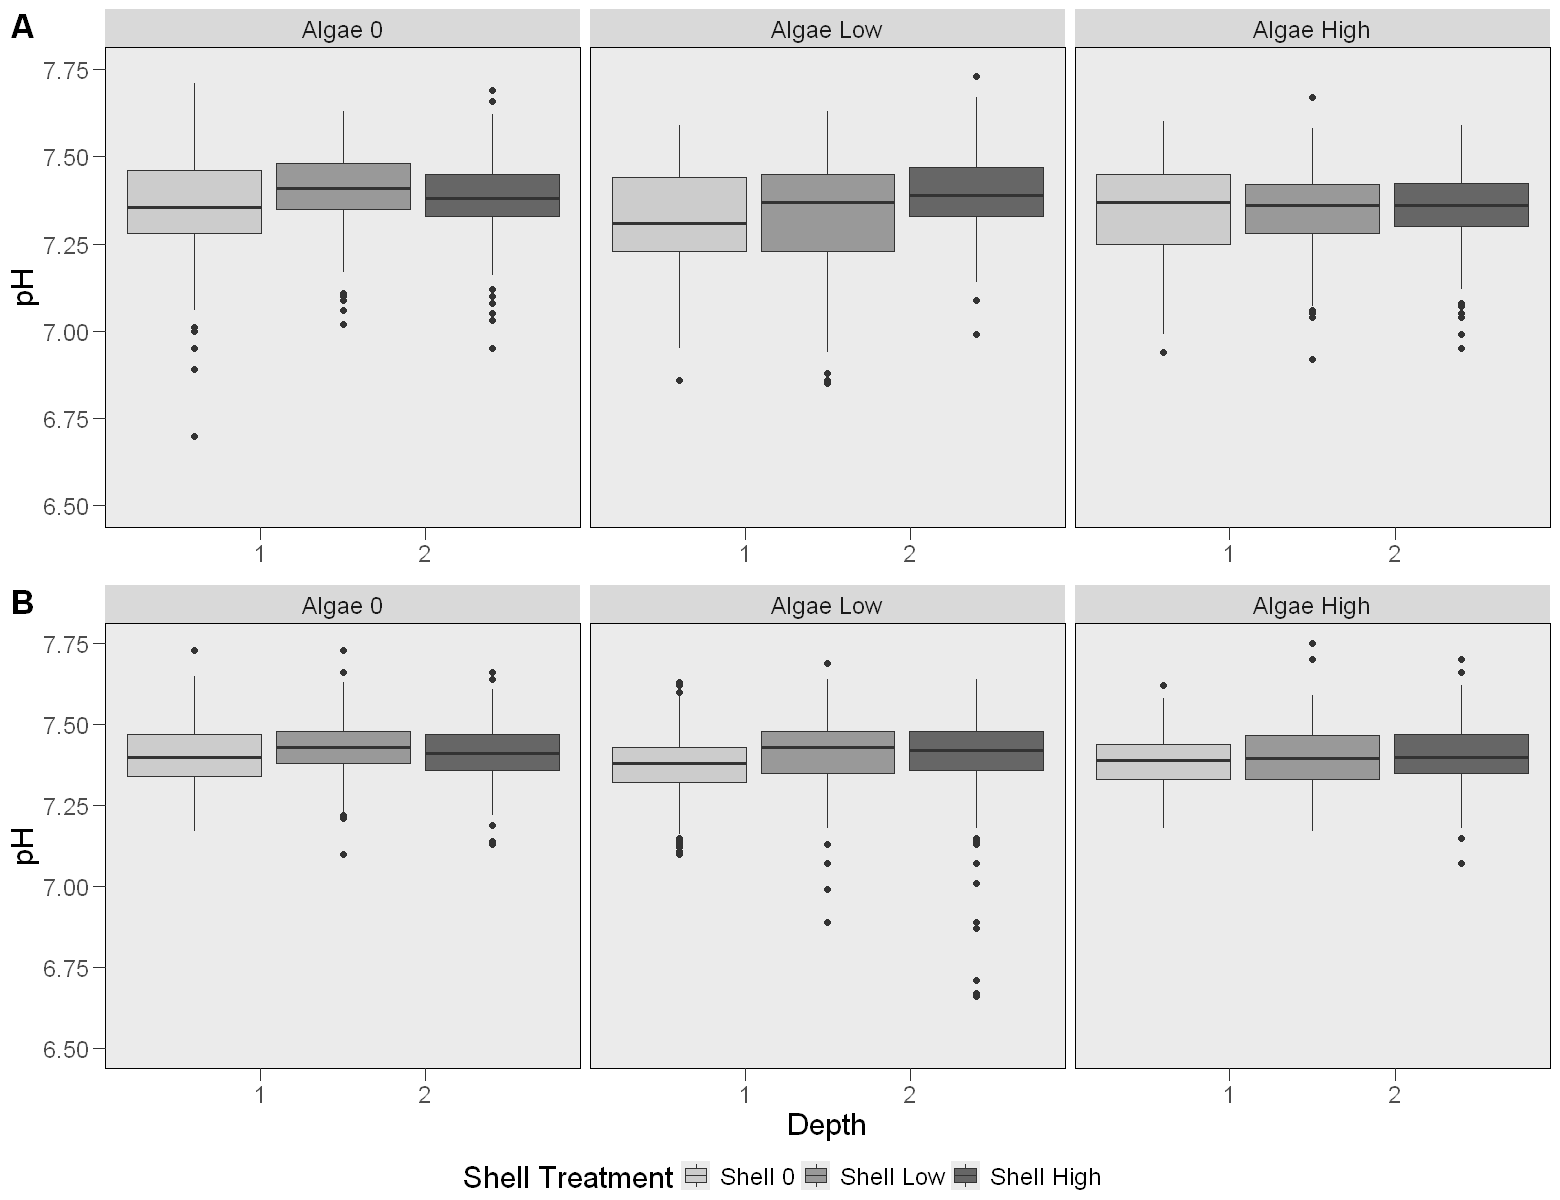

In [77]:
options(repr.plot.width = 13, repr.plot.height = 10)

# ── Figure 1: Sediment pH × Shell treatment × Depth × Algae treatment ─────────
M1_fig <- ggplot(ph_M1, aes(x = Depth, y = pH, fill = Trt_Shell)) +
  geom_boxplot() +
  xlab("Depth") + ylab("pH") + ylim(6.5, 7.75) +
  scale_fill_manual(values = cbb, name = "Shell Treatment",
                    labels = c("Shell 0", "Shell Low", "Shell High")) +
  facet_grid(. ~ Trt_Nut, scales = "free", space = "free",
             labeller = labeller(Trt_Nut = Trt_Nut.labs)) +
  theme_base(base_size = 18)

M2_fig <- ggplot(ph_M2, aes(x = Depth, y = pH, fill = Trt_Shell)) +
  geom_boxplot() +
  xlab("Depth") + ylab("pH") + ylim(6.5, 7.75) +
  scale_fill_manual(values = cbb, name = "Shell Treatment",
                    labels = c("Shell 0", "Shell Low", "Shell High")) +
  facet_grid(. ~ Trt_Nut, scales = "free", space = "free",
             labeller = labeller(Trt_Nut = Trt_Nut.labs)) +
  theme_base(base_size = 18)

ggarrange(M1_fig + rremove("xlab"), M2_fig,
          labels = c("A", "B"), ncol = 1, nrow = 2,
          font.label = list(size = 20),
          common.legend = TRUE, legend = "bottom")

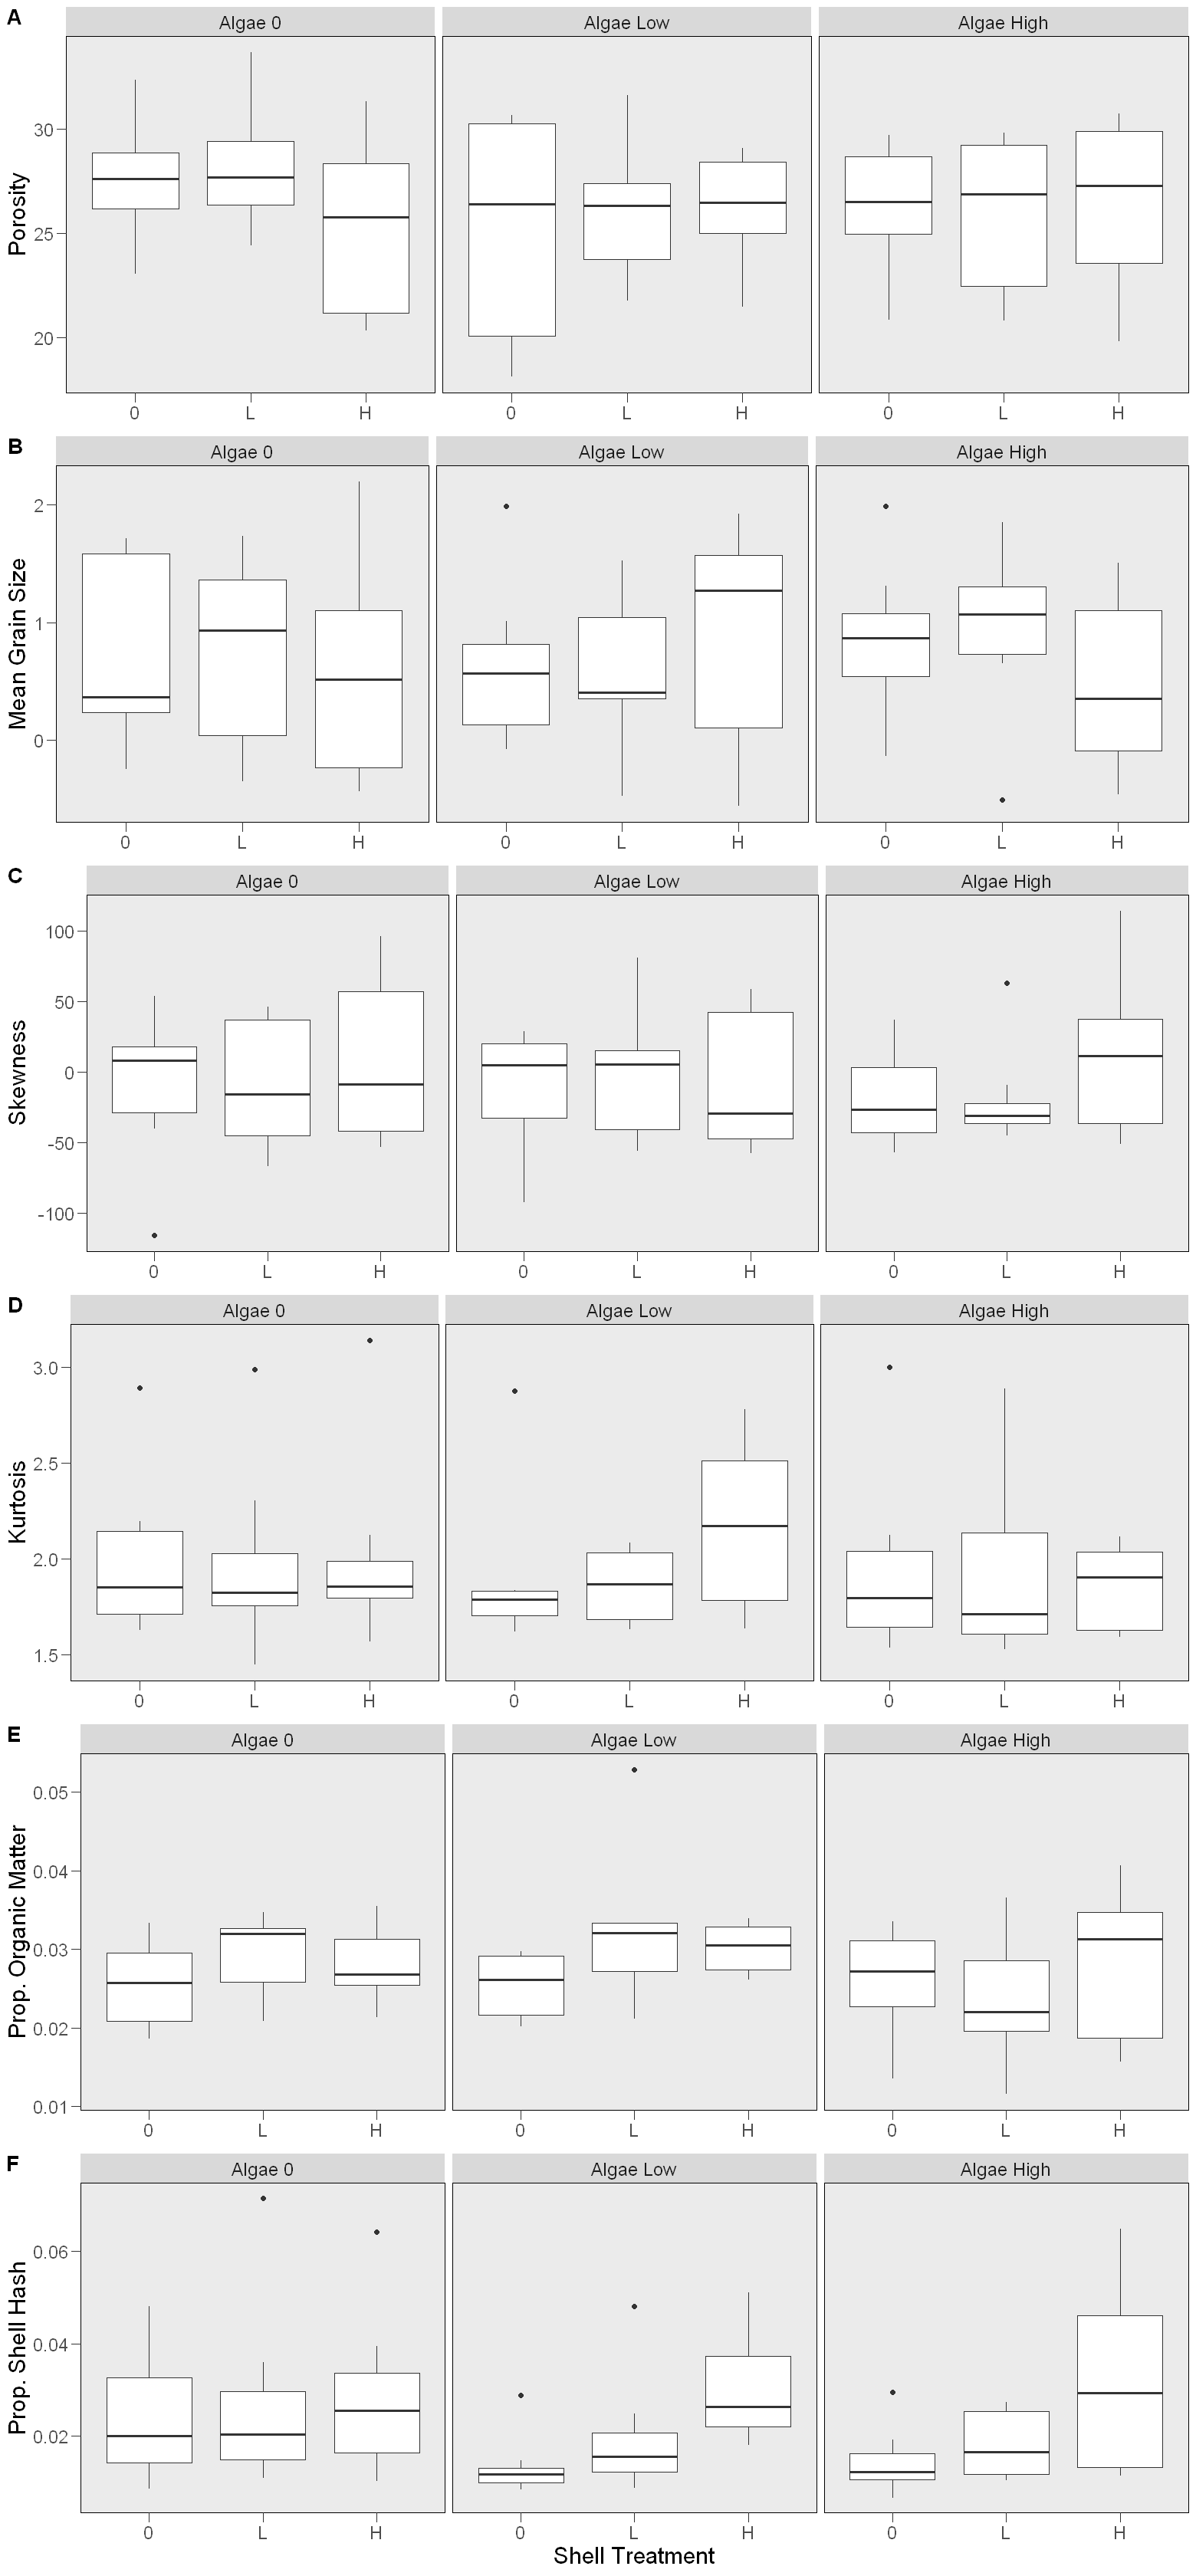

In [78]:
options(repr.plot.width = 13, repr.plot.height = 28)

# ── Figure 2: Sediment characteristics ───────────────────────────────────────
fig_poro <- ggplot(grain1, aes(x = Trt_Shell, y = porosity)) +
  geom_boxplot() + xlab("Shell Treatment") + ylab("Porosity") +
  facet_grid(. ~ Trt_Nut, labeller = labeller(Trt_Nut = Trt_Nut.labs)) +
  theme_base(base_size = 18)

fig_mean <- ggplot(grain1, aes(x = Trt_Shell, y = Mean)) +
  geom_boxplot() + xlab("Shell Treatment") + ylab("Mean Grain Size") +
  facet_grid(. ~ Trt_Nut, labeller = labeller(Trt_Nut = Trt_Nut.labs)) +
  theme_base(base_size = 18)

fig_skew <- ggplot(grain1, aes(x = Trt_Shell, y = Skewness)) +
  geom_boxplot() + xlab("Shell Treatment") + ylab("Skewness") +
  facet_grid(. ~ Trt_Nut, labeller = labeller(Trt_Nut = Trt_Nut.labs)) +
  theme_base(base_size = 18)

fig_kurt <- ggplot(grain1, aes(x = Trt_Shell, y = Kurtosis)) +
  geom_boxplot() + xlab("Shell Treatment") + ylab("Kurtosis") +
  facet_grid(. ~ Trt_Nut, labeller = labeller(Trt_Nut = Trt_Nut.labs)) +
  theme_base(base_size = 18)

fig_OM <- ggplot(omsh1, aes(x = Trt_Shell, y = OM)) +
  geom_boxplot() + xlab("Shell Treatment") + ylab("Prop. Organic Matter") +
  facet_grid(. ~ Trt_Nut, labeller = labeller(Trt_Nut = Trt_Nut.labs)) +
  theme_base(base_size = 18)

fig_carb <- ggplot(omsh1, aes(x = Trt_Shell, y = Carb)) +
  geom_boxplot() + xlab("Shell Treatment") + ylab("Prop. Shell Hash") +
  facet_grid(. ~ Trt_Nut, labeller = labeller(Trt_Nut = Trt_Nut.labs)) +
  theme_base(base_size = 18)

ggarrange(fig_poro + rremove("xlab"),
          fig_mean + rremove("xlab"),
          fig_skew + rremove("xlab"),
          fig_kurt + rremove("xlab"),
          fig_OM   + rremove("xlab"),
          fig_carb,
          labels       = c("A","B","C","D","E","F"),
          ncol         = 1, nrow = 6,
          font.label   = list(size = 16),
          common.legend = TRUE, legend = "top")

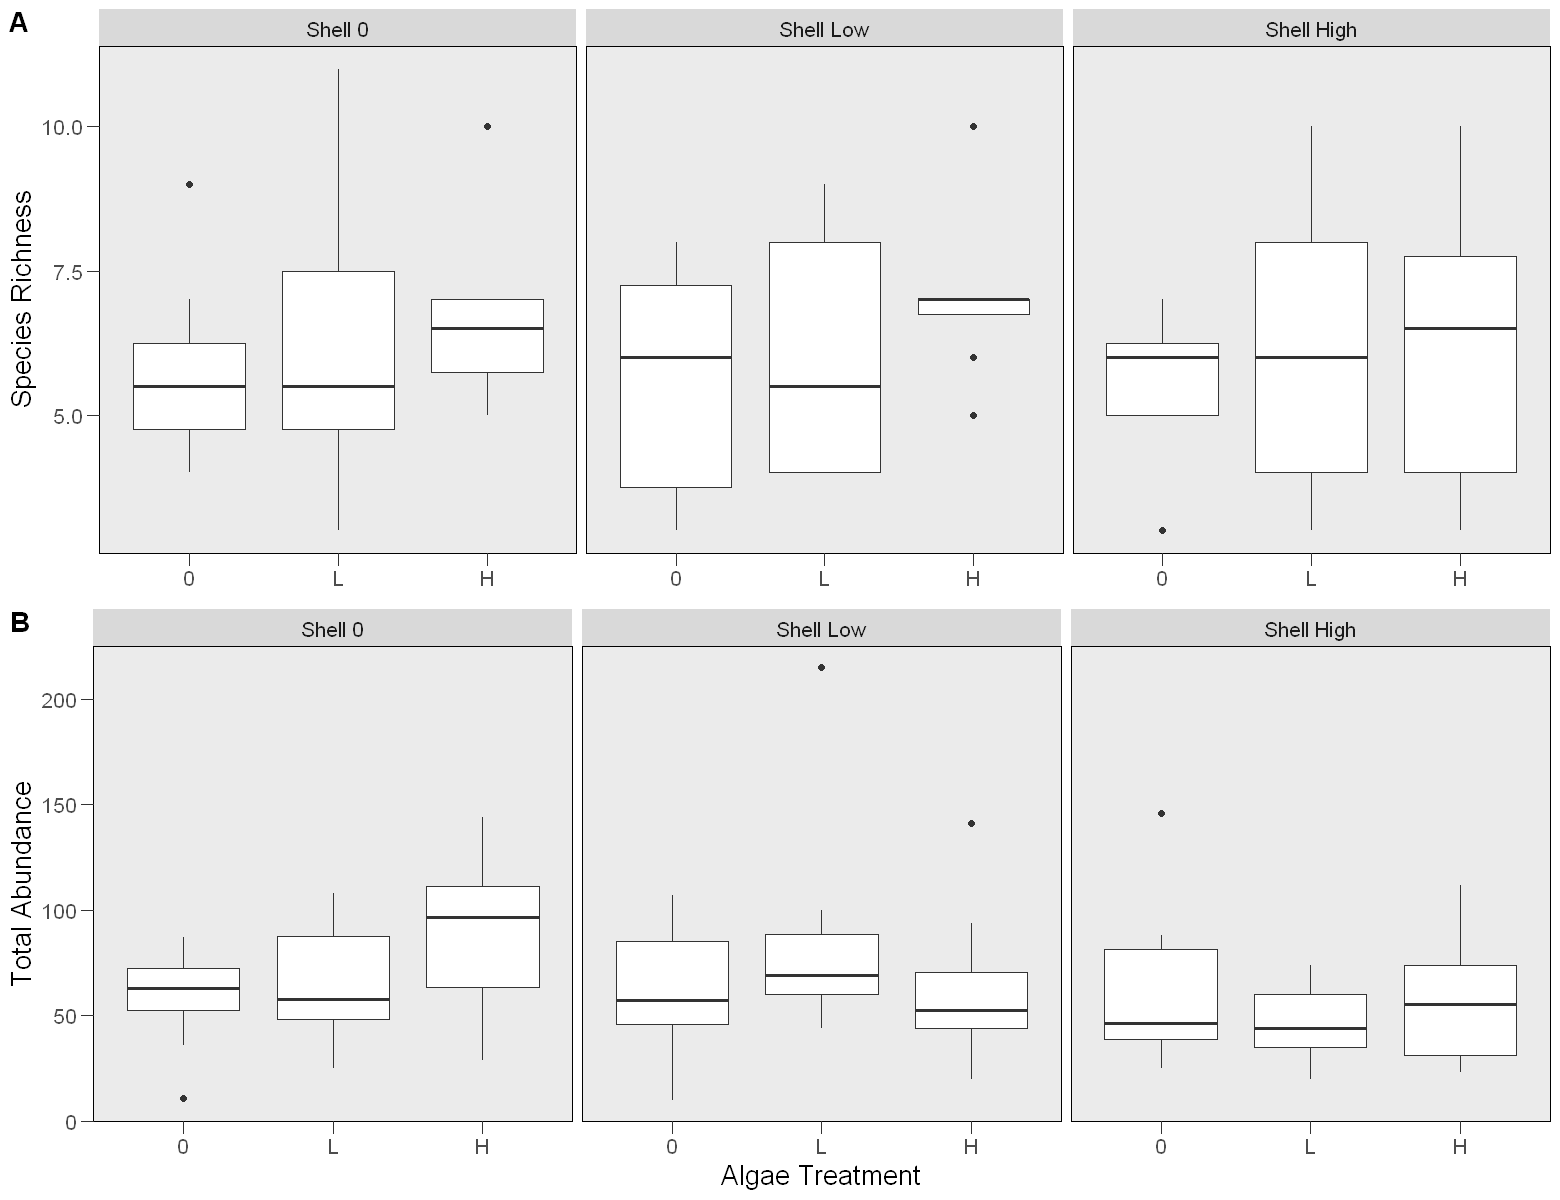

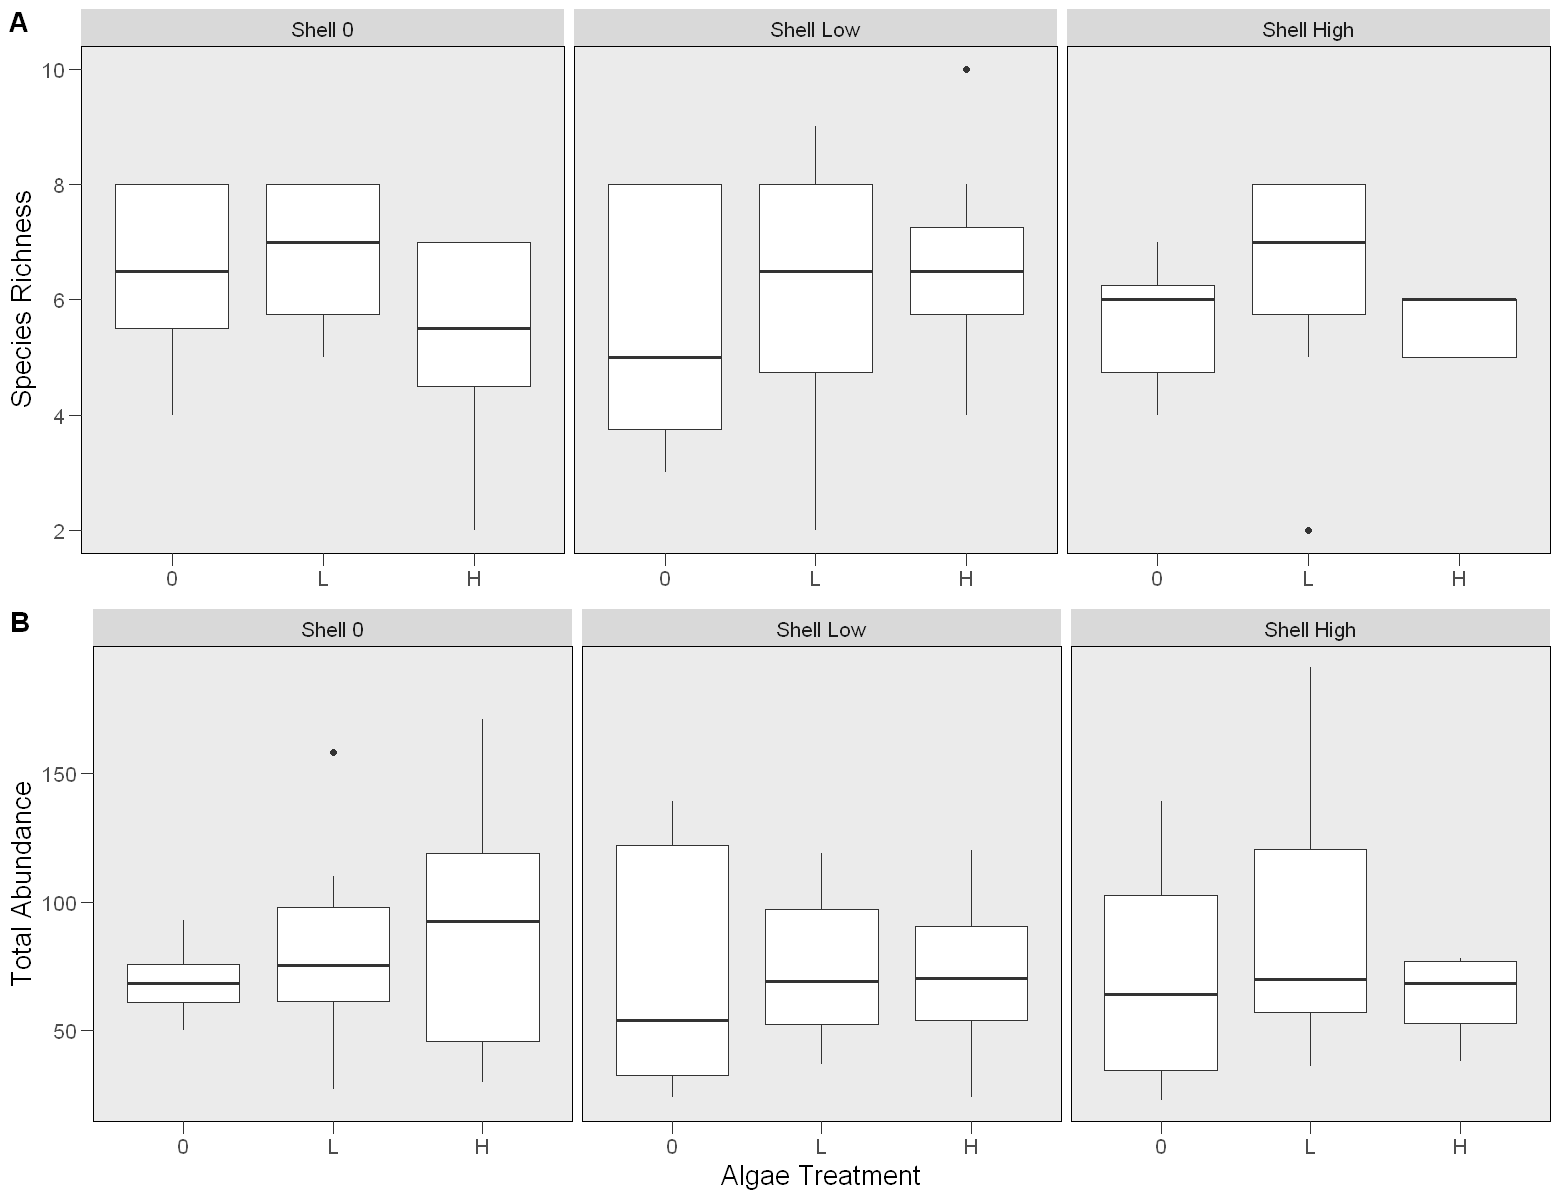

In [79]:
options(repr.plot.width = 13, repr.plot.height = 10)

# ── Figure 3: Univariate biodiversity — Month 1 and Month 2 ───────────────────
rich1 <- ggplot(unibio1, aes(x = Trt_Nut, y = S)) +
  geom_boxplot() + xlab("Algae Treatment") + ylab("Species Richness") +
  facet_grid(. ~ Trt_Shell, labeller = labeller(Trt_Shell = Trt_Shell.labs)) +
  theme_base(base_size = 16)
abund_fig1 <- ggplot(unibio1, aes(x = Trt_Nut, y = N)) +
  geom_boxplot() + xlab("Algae Treatment") + ylab("Total Abundance") +
  facet_grid(. ~ Trt_Shell, labeller = labeller(Trt_Shell = Trt_Shell.labs)) +
  theme_base(base_size = 16)

rich2 <- ggplot(unibio2, aes(x = Trt_Nut, y = S)) +
  geom_boxplot() + xlab("Algae Treatment") + ylab("Species Richness") +
  facet_grid(. ~ Trt_Shell, labeller = labeller(Trt_Shell = Trt_Shell.labs)) +
  theme_base(base_size = 16)
abund_fig2 <- ggplot(unibio2, aes(x = Trt_Nut, y = N)) +
  geom_boxplot() + xlab("Algae Treatment") + ylab("Total Abundance") +
  facet_grid(. ~ Trt_Shell, labeller = labeller(Trt_Shell = Trt_Shell.labs)) +
  theme_base(base_size = 16)

ggarrange(rich1 + rremove("xlab"), abund_fig1,
          labels = c("A", "B"), ncol = 1, nrow = 2,
          font.label = list(size = 16),
          common.legend = TRUE, legend = "top")

ggarrange(rich2 + rremove("xlab"), abund_fig2,
          labels = c("A", "B"), ncol = 1, nrow = 2,
          font.label = list(size = 16),
          common.legend = TRUE, legend = "top")

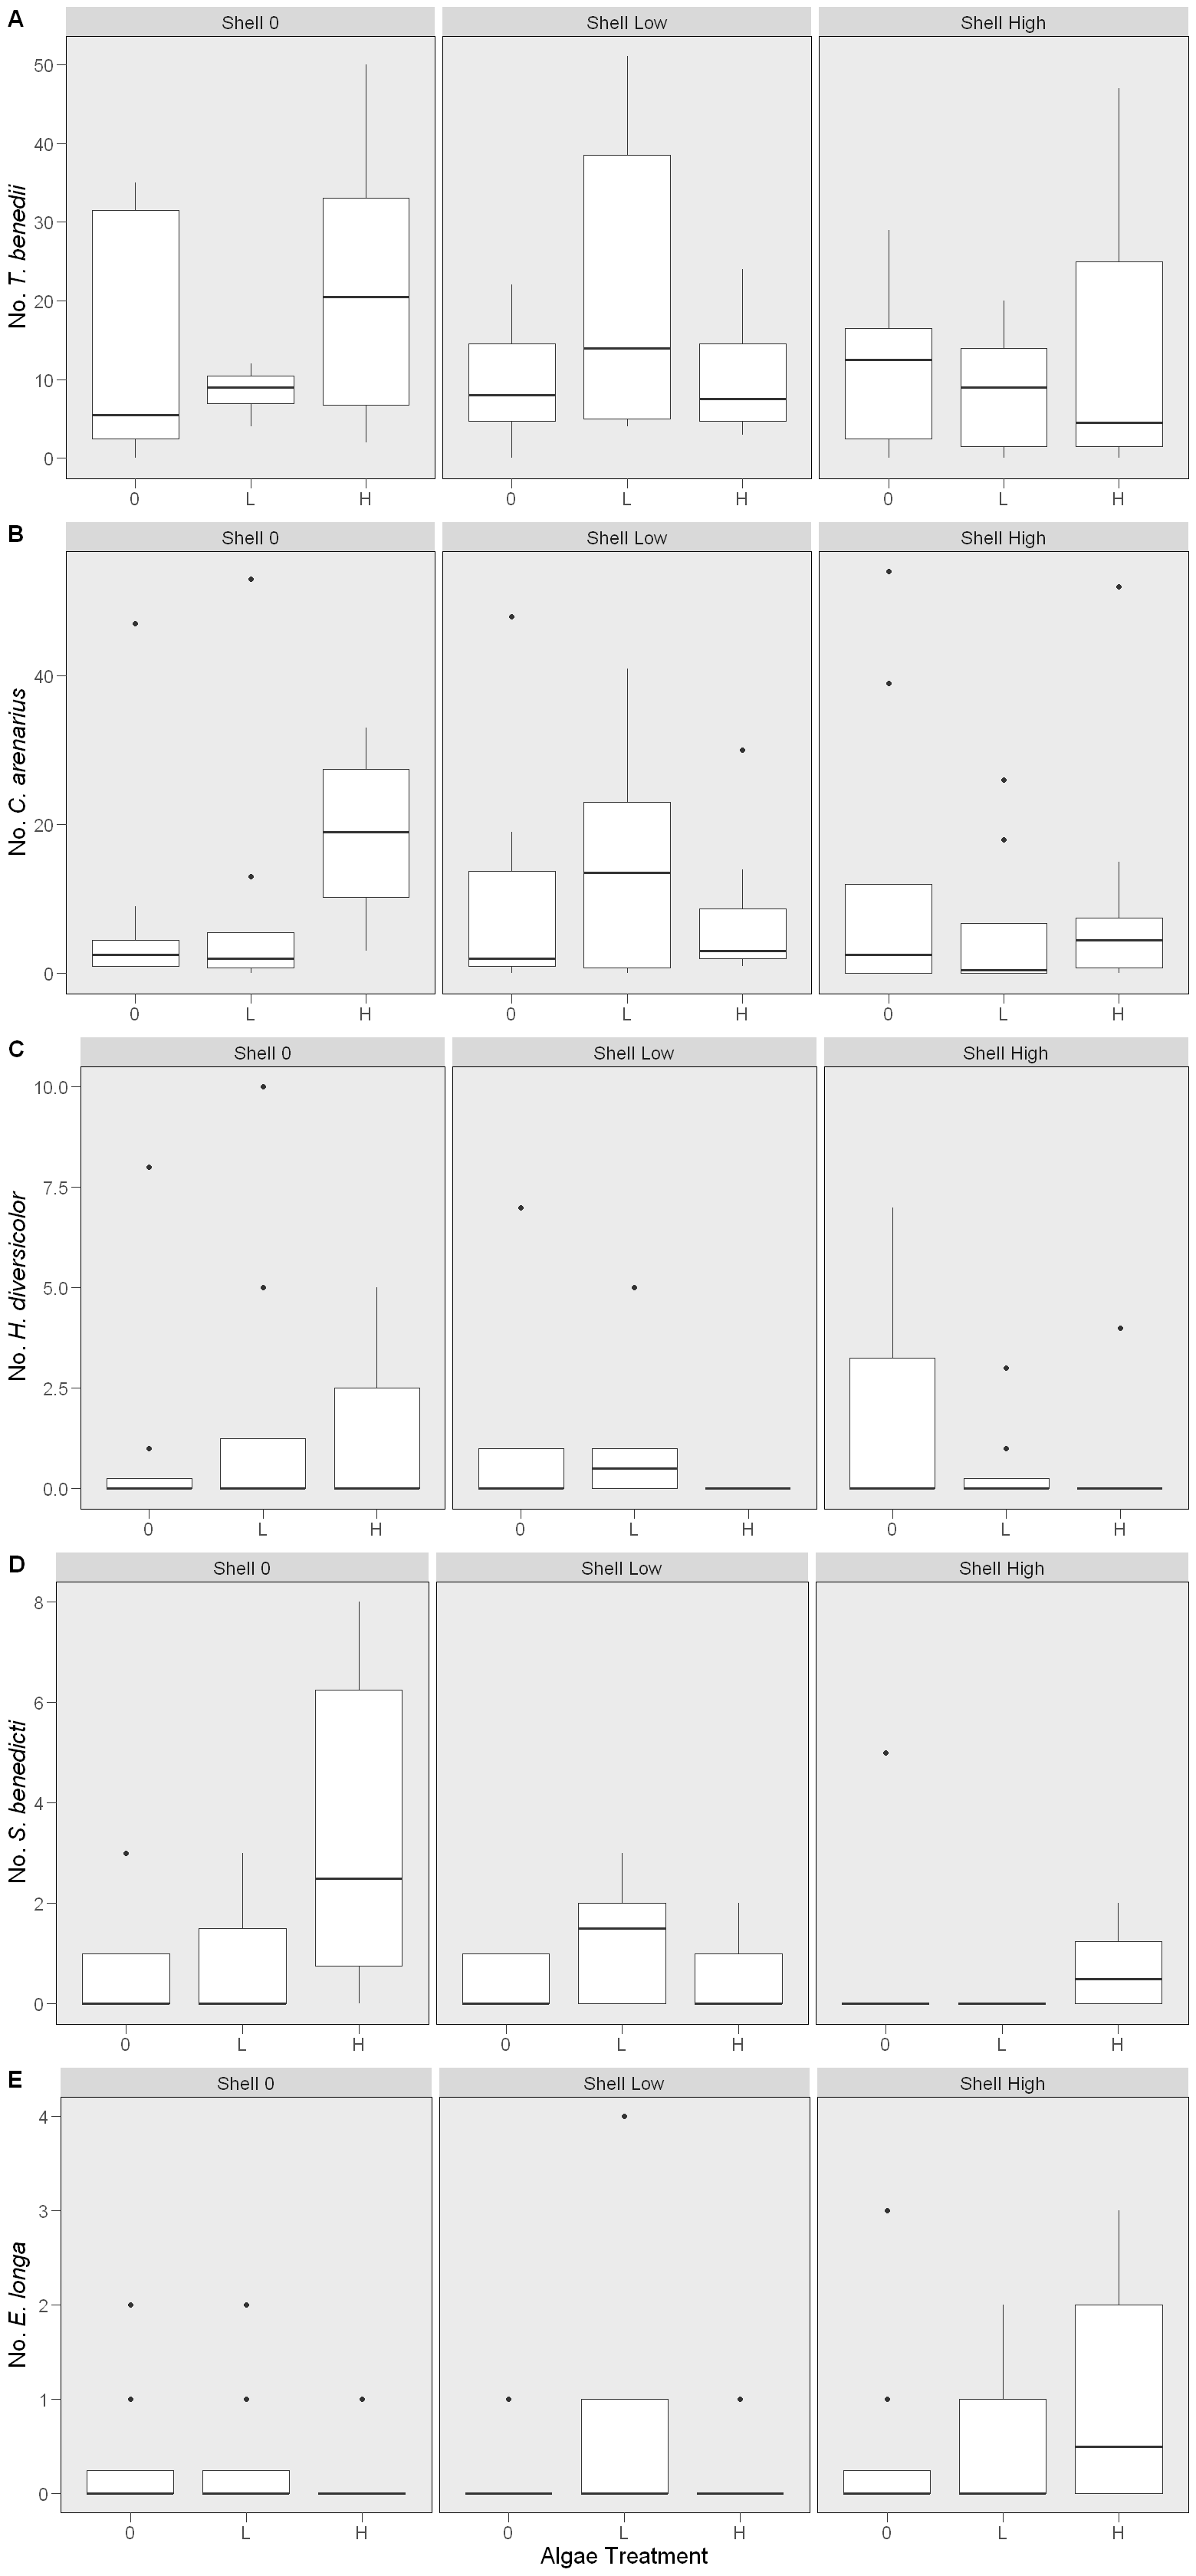

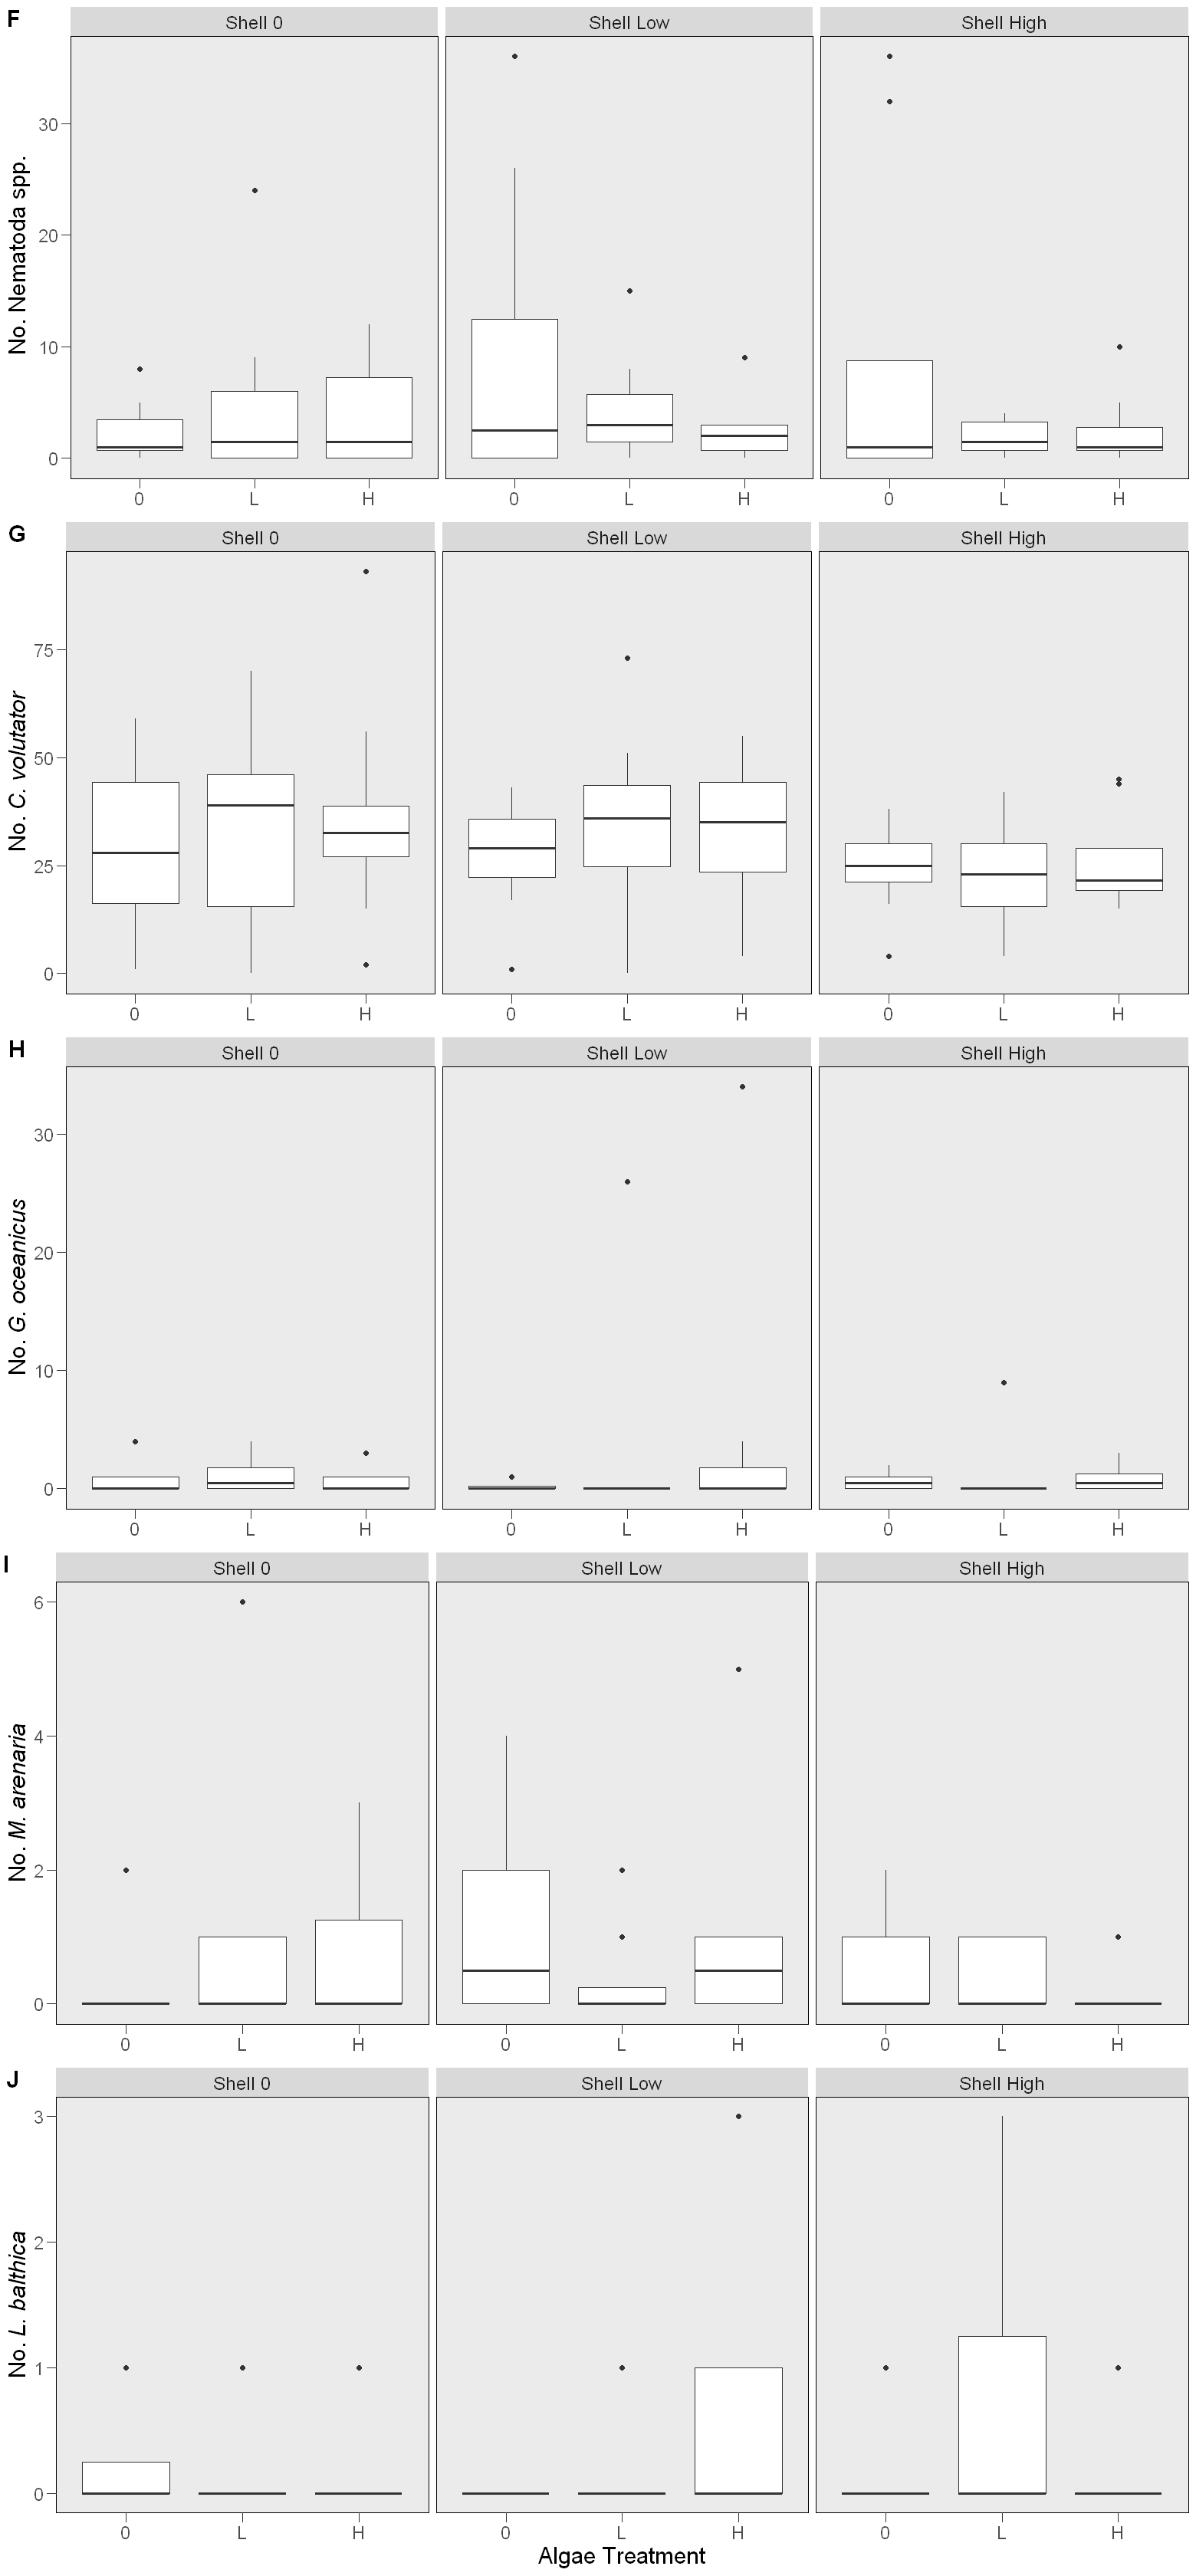

In [80]:
options(repr.plot.width = 13, repr.plot.height = 28)

# ── Figure 4: Individual species abundances — Month 1 ─────────────────────────
coro  <- ggplot(abund1, aes(x = Trt_Nut, y = Corophium)) +
  geom_boxplot() + xlab("Algae Treatment") +
  ylab(expression(paste("No. ", italic("C. volutator")))) +
  facet_grid(. ~ Trt_Shell, labeller = labeller(Trt_Shell = Trt_Shell.labs)) +
  theme_base(base_size = 18)
tub   <- ggplot(abund1, aes(x = Trt_Nut, y = Tubificoides)) +
  geom_boxplot() + xlab("Algae Treatment") +
  ylab(expression(paste("No. ", italic("T. benedii")))) +
  facet_grid(. ~ Trt_Shell, labeller = labeller(Trt_Shell = Trt_Shell.labs)) +
  theme_base(base_size = 18)
cli   <- ggplot(abund1, aes(x = Trt_Nut, y = Clitellio)) +
  geom_boxplot() + xlab("Algae Treatment") +
  ylab(expression(paste("No. ", italic("C. arenarius")))) +
  facet_grid(. ~ Trt_Shell, labeller = labeller(Trt_Shell = Trt_Shell.labs)) +
  theme_base(base_size = 18)
nem   <- ggplot(abund1, aes(x = Trt_Nut, y = Nematoda)) +
  geom_boxplot() + xlab("Algae Treatment") +
  ylab(expression(paste("No. Nematoda spp."))) +
  facet_grid(. ~ Trt_Shell, labeller = labeller(Trt_Shell = Trt_Shell.labs)) +
  theme_base(base_size = 18)
mya   <- ggplot(abund1, aes(x = Trt_Nut, y = Mya)) +
  geom_boxplot() + xlab("Algae Treatment") +
  ylab(expression(paste("No. ", italic("M. arenaria")))) +
  facet_grid(. ~ Trt_Shell, labeller = labeller(Trt_Shell = Trt_Shell.labs)) +
  theme_base(base_size = 18)
hed   <- ggplot(abund1, aes(x = Trt_Nut, y = Hediste)) +
  geom_boxplot() + xlab("Algae Treatment") +
  ylab(expression(paste("No. ", italic("H. diversicolor")))) +
  facet_grid(. ~ Trt_Shell, labeller = labeller(Trt_Shell = Trt_Shell.labs)) +
  theme_base(base_size = 18)
streb <- ggplot(abund1, aes(x = Trt_Nut, y = Streblospio)) +
  geom_boxplot() + xlab("Algae Treatment") +
  ylab(expression(paste("No. ", italic("S. benedicti")))) +
  facet_grid(. ~ Trt_Shell, labeller = labeller(Trt_Shell = Trt_Shell.labs)) +
  theme_base(base_size = 18)
lime  <- ggplot(abund1, aes(x = Trt_Nut, y = Limecola)) +
  geom_boxplot() + xlab("Algae Treatment") +
  ylab(expression(paste("No. ", italic("L. balthica")))) +
  facet_grid(. ~ Trt_Shell, labeller = labeller(Trt_Shell = Trt_Shell.labs)) +
  theme_base(base_size = 18)
eteone <- ggplot(abund1, aes(x = Trt_Nut, y = Eteone)) +
  geom_boxplot() + xlab("Algae Treatment") +
  ylab(expression(paste("No. ", italic("E. longa")))) +
  facet_grid(. ~ Trt_Shell, labeller = labeller(Trt_Shell = Trt_Shell.labs)) +
  theme_base(base_size = 18)
gamm  <- ggplot(abund1, aes(x = Trt_Nut, y = Gammarus)) +
  geom_boxplot() + xlab("Algae Treatment") +
  ylab(expression(paste("No. ", italic("G. oceanicus")))) +
  facet_grid(. ~ Trt_Shell, labeller = labeller(Trt_Shell = Trt_Shell.labs)) +
  theme_base(base_size = 18)

ggarrange(tub   + rremove("xlab"),
          cli   + rremove("xlab"),
          hed   + rremove("xlab"),
          streb + rremove("xlab"),
          eteone,
          labels = c("A","B","C","D","E"),
          ncol = 1, nrow = 5,
          font.label = list(size = 18),
          common.legend = TRUE, legend = "top")

ggarrange(nem   + rremove("xlab"),
          coro  + rremove("xlab"),
          gamm  + rremove("xlab"),
          mya   + rremove("xlab"),
          lime,
          labels = c("F","G","H","I","J"),
          ncol = 1, nrow = 5,
          font.label = list(size = 18),
          common.legend = TRUE, legend = "top")

Warning message:
"Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`)."
Warning message:
"Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`)."
Warning message:
"Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`)."
Warning message:
"Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`)."


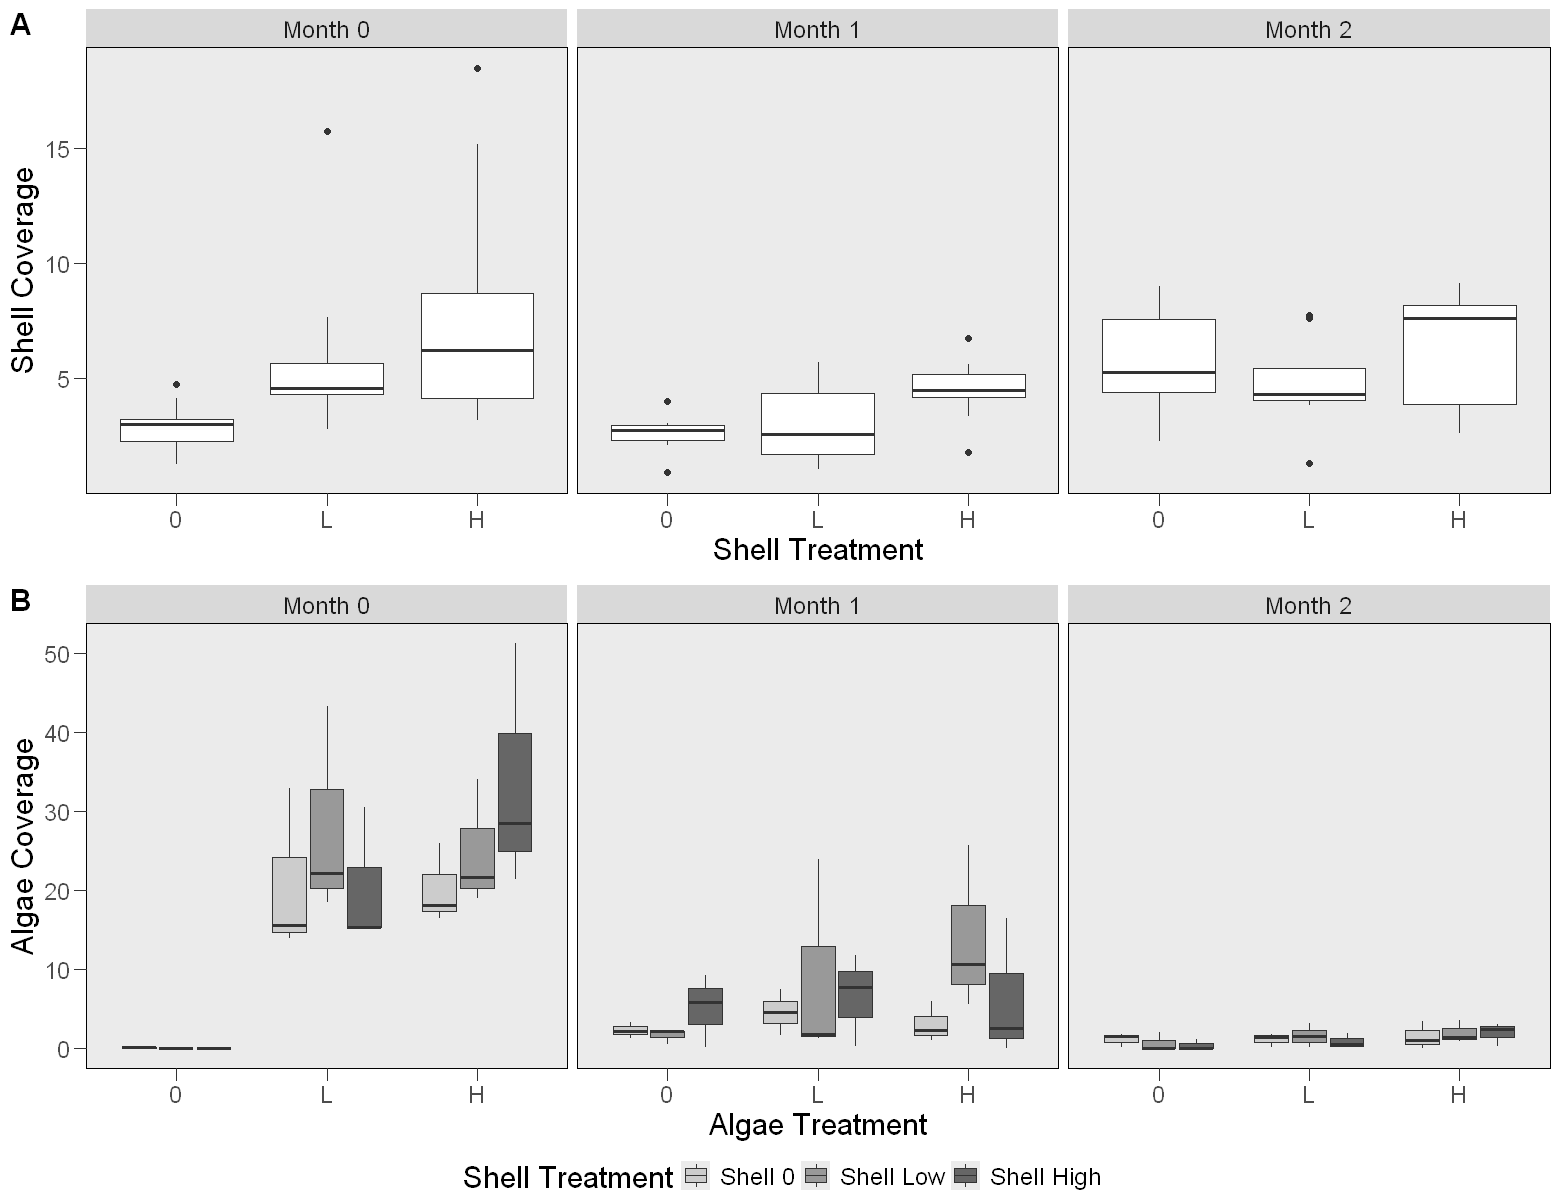

In [81]:
options(repr.plot.width = 13, repr.plot.height = 10)

# ── Figure 5: Treatment coverage ──────────────────────────────────────────────
fig_shell_cov <- ggplot(cover_trt, aes(x = Trt_Shell, y = Shell)) +
  geom_boxplot() + xlab("Shell Treatment") + ylab("Shell Coverage") +
  facet_grid(. ~ Month, labeller = labeller(Month = Month.labs)) +
  theme_base(base_size = 18)

fig_algae_cov <- ggplot(cover_trt, aes(x = Trt_Nut, y = Algae, fill = Trt_Shell)) +
  geom_boxplot() + xlab("Algae Treatment") + ylab("Algae Coverage") +
  scale_fill_manual(values = cbb, name = "Shell Treatment",
                    labels = c("Shell 0", "Shell Low", "Shell High")) +
  facet_grid(. ~ Month, labeller = labeller(Month = Month.labs)) +
  theme_base(base_size = 18)

ggarrange(fig_shell_cov, fig_algae_cov,
          labels = c("A", "B"), ncol = 1, nrow = 2,
          font.label    = list(size = 18),
          common.legend = TRUE, legend = "bottom")

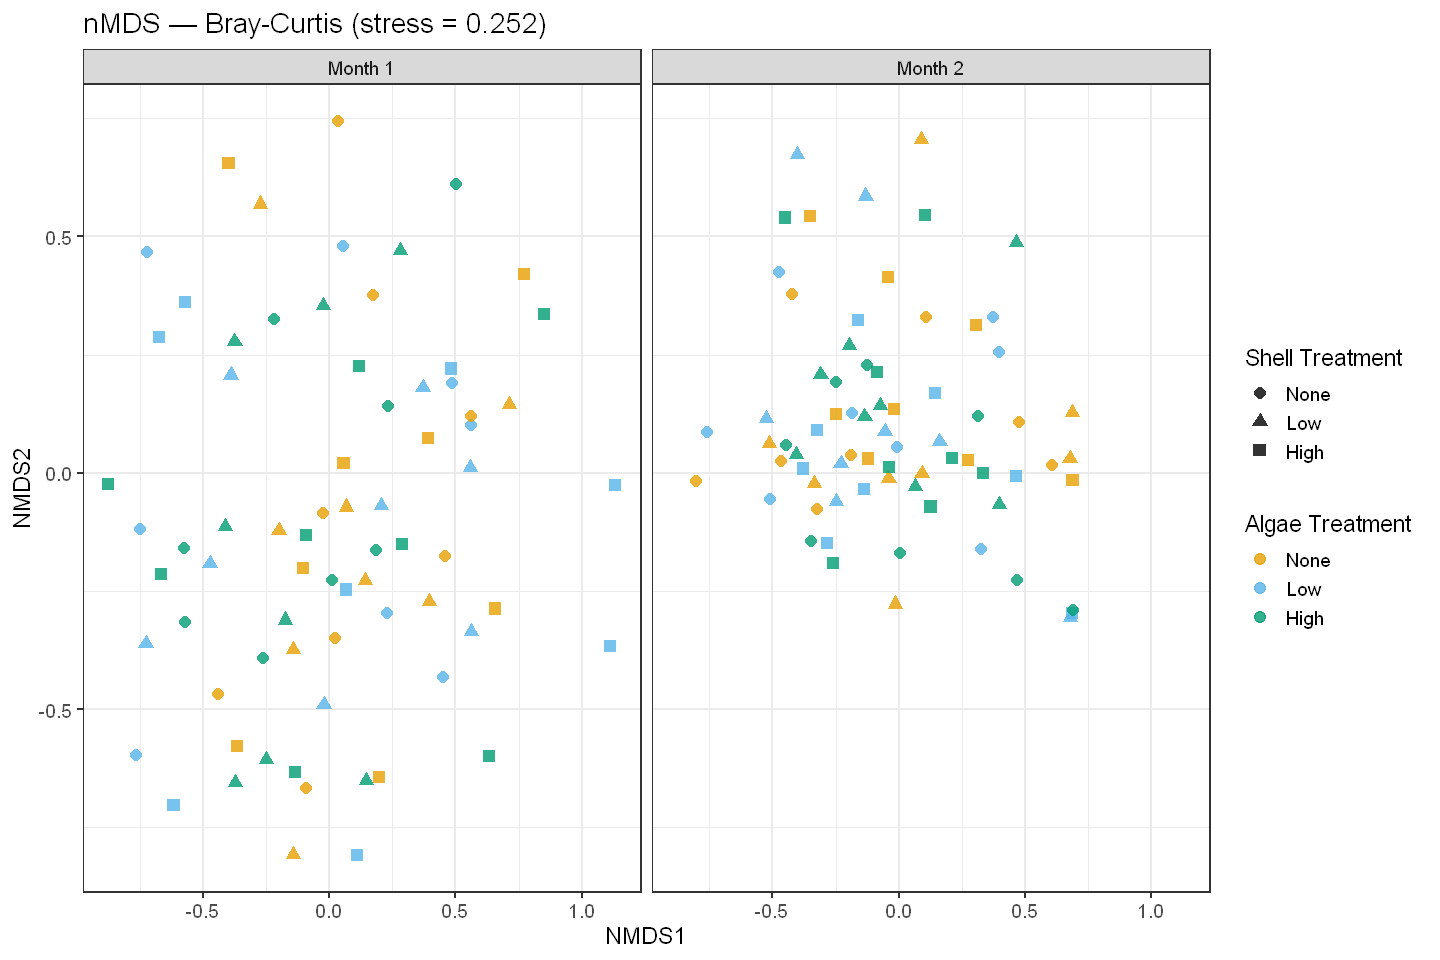

In [82]:
options(repr.plot.width = 12, repr.plot.height = 8)

# ── Figure 6: nMDS ordination ─────────────────────────────────────────────────
ggplot(nmds_scores, aes(x = NMDS1, y = NMDS2,
                        color = Trt_Nut, shape = Trt_Shell)) +
  geom_point(size = 3, alpha = 0.8) +
  facet_wrap(~ Month, labeller = labeller(Month = Month.labs)) +
  scale_color_manual(values = c("#E69F00", "#56B4E9", "#009E73"),
                     name   = "Algae Treatment",
                     labels = c("None", "Low", "High")) +
  scale_shape_manual(values = c(16, 17, 15),
                     name   = "Shell Treatment",
                     labels = c("None", "Low", "High")) +
  labs(title = paste0("nMDS — Bray-Curtis (stress = ",
                      round(nmds$stress, 3), ")")) +
  theme_bw(base_size = 14)